# AI-Based Diabetes Risk Prediction System Using Clinical and Lifestyle Factors

"""
This script builds and evaluates machine learning models to predict diabetes risk
using the Pima Indians Diabetes Dataset.
"""

- This script builds and evaluates machine learning models to predict diabetes risk using the Pima Indians Diabetes Dataset with 12 advanced optimization techniques:

1. Feature Engineering (Medical domain features)
3. Feature Selection (Hybrid RFE + univariate)
4. Cost-Sensitive Learning (Weighted for medical costs)
5. Hyperparameter Optimization (Expanded search spaces)
6. Threshold Optimization (Multi-objective with business constraints)
7. Enhanced Custom Scoring Function
8. Multiple Ensemble Strategies (Equal Weight Voting Ensemble, Performance-Weighted Voting Ensemble, Stability-Weighted Voting Ensemble)
9. Cross-Validation Analysis (Uses StratifiedKFold with 5 folds)
10. Learning Curve Analysis (Overfitting detection and generalization assessment)
11. Comprehensive Model Portfolio (Creates 13 different models with various algorithms)
12. Model Ranking and Selection (Ranks models by combined score (60% custom score + 30% CV performance + 10% stability) and selects top 8 for ensemble)
13. Detailed Performance Metrics (medical-relevant metrics)
14. Interactive Deployment System (Complete medical assessment interface)










In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.9 MB/s eta 0:00:00


### ----- LIBRARY IMPORTS -----

In [ ]:
# Core data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Warning handling
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Core ML libraries
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve,
    validation_curve, GridSearchCV, RandomizedSearchCV
)
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier,
    StackingClassifier, ExtraTreesClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Preprocessing and imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif

# Sampling techniques
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours, RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

# Metrics and evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, roc_auc_score, make_scorer,
    precision_score, recall_score, f1_score, accuracy_score
)

# Hyperparameter optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression

# Utilities
from sklearn.utils.class_weight import compute_class_weight
import joblib
import datetime


### ----- DATA LOADING -----

In [ ]:

# Direct download link for the Pima Indians Diabetes Dataset

data_url = "https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database"
data_path = "./diabetes.csv"


# Reading the dataset
df = pd.read_csv(data_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Dataset Features:
- Pregnancies count
- Glucose concentration (2-hour oral glucose tolerance test, mg/dL)
- Blood pressure (diastolic, mm Hg)
- Skin thickness (triceps skinfold, mm)
- Insulin level (2-hour serum insulin, mu U/ml)
- Body Mass Index (BMI, kg/m^2)
- Diabetes pedigree function (genetic risk factor)
- Age (years)

#### Displaying the basic dataset information

In [ ]:
print("Shape:", df.shape)
print("\nDataset Information:")
print(df.info())
print("\nChecking for null values")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())
print(f"\nTarget distribution:\n{df['Outcome'].value_counts()}")


Shape: (768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Checking for null values
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                  

In [ ]:
# Identifying zeros as missing values
print("\nZeros count in columns (possible missing data):")

# Defining columns with missing data (zeros)
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zeros_count = (df[missing_cols] == 0).sum()
zeros_pct = (zeros_count / len(df) * 100).round(2)

for col in missing_cols:
    print(f"   {col}: {zeros_count[col]} zeros ({zeros_pct[col]}%)")


Zeros count in columns (possible missing data):
   Glucose: 5 zeros (0.65%)
   BloodPressure: 35 zeros (4.56%)
   SkinThickness: 227 zeros (29.56%)
   Insulin: 374 zeros (48.7%)
   BMI: 11 zeros (1.43%)


### ----- MULTIPLE IMPUTATION IMPLEMENTATION WITH FEATURE ENGINEERING -----

- "By observation and medical knowledge, it is not possible for a living patient to have zero values for the following: 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI'. Hence, the zeros represent missing values that need to be addressed."


### Why MICE (Mutiple Imputation by Chained Equations) is Optimal for the Pima Indian Diabetes Dataset

MICE represents the most sophisticated approach for handling missing data in the Pima Indian Diabetes dataset due to several critical factors:

#### Dataset-Specific Challenges
The Pima dataset presents unique data quality issues where missing values are incorrectly encoded as zeros in physiological measurements including glucose, blood pressure, insulin, and BMI. These zero values are biologically impossible for living patients, creating systematic missingness patterns that require advanced imputation techniques to address properly.

#### MICE Advantages Over Traditional Methods
**Relationship-Based Imputation**: MICE leverages the complex correlations between physiological variables, such as the intricate relationships between BMI, glucose levels, and age, rather than relying on simplistic statistical measures like mean or median substitution.

**Iterative Refinement Process**: The algorithm performs multiple rounds of imputation, allowing imputed values to stabilize based on variable interdependencies. This iterative approach captures imputation uncertainty more effectively than single-point estimations used in mean or median imputation methods.
___
### **Enhanced Feature Engineering Integration**

The implementation incorporates sophisticated feature engineering that complements MICE's capabilities:

#### Categorical Binning Features
- **BMI Categories**: Classifies patients as Underweight (<18.5), Normal (18.5-25), Overweight (25-30), or Obese (>30) following clinical standards
- **Glucose Levels**: Distinguishes Normal Glucose (<100), Elevated Glucose (100-126), and Marked Hyperglycemia (>126) based on diagnostic thresholds

#### Clinical Risk Scores
- **Metabolic Risk Score**: Aggregates multiple risk factors (hyperglycemia, obesity, hypertension) into a composite score
- **High-Risk Pregnancy Indicator**: Flags patients with elevated pregnancy counts (>4) associated with increased diabetes risk

### Strategic Advantages

This enhanced MICE implementation provides superior predictive modeling capabilities by combining sophisticated missing data handling with clinically meaningful feature engineering. The approach preserves the natural relationships within the data while creating new features that capture complex physiological interactions, ultimately improving model performance and interpretability for diabetes prediction tasks.

In [ ]:
def extra_medical_features_and_multiple_imputation_pipeline(df, n_imputations=5, random_state_base=42):
    """
    Performs Multiple Imputation and creates a preprocessing pipeline with Feature Engineering

    Parameters:
    - df: Input dataframe
    - n_imputations: Number of imputation rounds (default 5)
    - random_state_base: Base random state for reproducibility

    Returns:
    - enhanced_dataset: DataFrame with averaged imputations and engineered features
    - preprocessing_pipeline: Dictionary containing all preprocessing components
    - imputation_uncertainty: Uncertainty estimates for imputed values
    """

    print("STEP 1: Multiple Imputation Setup...")
    print("=" * 60)

    # Step 1: Replacing zeros with NaN
    df_prep = df.copy()
    df_prep[missing_cols] = df_prep[missing_cols].replace(0, np.nan)

    # Step 2: Creating multiple imputed datasets
    print(f"\nSTEP 2: Creating {n_imputations} imputed datasets")

    # Step 2.5: Calculate intelligent clipping bounds (before imputation loop)
    def calculate_smart_bounds(df_original, column):
        """Calculate intelligent clipping bounds using quantiles + medical limits"""
        MEDICAL_LIMITS = {
            'Insulin': {'min': 2, 'max': 500},
            'Glucose': {'min': 60, 'max': 250},
            'BloodPressure': {'min': 50, 'max': 150},
            'SkinThickness': {'min': 7, 'max': 70},
            'BMI': {'min': 12, 'max': 80}
        }

        # Remove zeros (missing values) for boundary calculation
        clean_data = df_original[df_original[column] > 0][column]

        # Use quantiles with medical constraints
        Q1, Q3 = clean_data.quantile([0.25, 0.75])
        IQR = Q3 - Q1

        # Calculate bounds (more generous upper bound for medical data)
        lower_bound = max(Q1 - 1.5 * IQR, MEDICAL_LIMITS[column]['min'])
        upper_bound = min(Q3 + 3.0 * IQR, MEDICAL_LIMITS[column]['max'])

        return lower_bound, upper_bound

    # Calculate clipping bounds once using original data
    CLIPPING_BOUNDS = {}
    for col in ['Insulin', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI']:
        if col in df.columns:
            CLIPPING_BOUNDS[col] = calculate_smart_bounds(df, col)

    print(f"\n📊 Calculated intelligent clipping bounds:")
    for col, (min_b, max_b) in CLIPPING_BOUNDS.items():
        print(f"  {col}: [{min_b:.1f}, {max_b:.1f}]")

    # Step 3: Multiple imputation with intelligent clipping
    imputed_datasets = []
    all_imputers = []

    for i in range(n_imputations):
        print(f"Running imputation #{i+1}...")

        # Create the imputer
        imputer = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=10,
                max_depth=5,
                random_state=random_state_base + i
            ),
            random_state=random_state_base + i,
            max_iter=10,
            min_value=0
        )

        # Fitting and transforming
        df_imputed = df_prep.copy()
        df_imputed[missing_cols] = imputer.fit_transform(df_prep[missing_cols])

        # Apply intelligent clipping
        for col, (min_bound, max_bound) in CLIPPING_BOUNDS.items():
            if col in df_imputed.columns:
                df_imputed[col] = np.clip(df_imputed[col], min_bound, max_bound)

        # Store results
        imputed_datasets.append(df_imputed)
        all_imputers.append(imputer)

    print("✅ All imputations completed with intelligent clipping!")

    # Step 3: Combining results and calculating uncertainty
    print("\nSTEP 3: Combining results and calculating uncertainty...")

    final_dataset = df_prep.copy()
    imputation_uncertainty = {}

    for col in missing_cols:
        # Getting all imputed values for this column across all datasets
        all_imputations = np.array([dataset[col].values for dataset in imputed_datasets])

        # Calculating mean imputation (average across all 5 imputations)
        mean_imputation = np.mean(all_imputations, axis=0)

        # Calculating uncertainty (standard deviation across imputations)
        uncertainty = np.std(all_imputations, axis=0)

        # Filling the final dataset with averaged values
        final_dataset[col] = mean_imputation

        # Storing uncertainty metrics for missing values
        missing_mask = df_prep[col].isnull()
        if missing_mask.sum() > 0:
            imputation_uncertainty[col] = {
                'mean': mean_imputation[missing_mask],
                'std': uncertainty[missing_mask],
                'confidence_interval': {
                    'lower': mean_imputation[missing_mask] - 1.96 * uncertainty[missing_mask],
                    'upper': mean_imputation[missing_mask] + 1.96 * uncertainty[missing_mask]
                }
            }

    # Step 4: Feature Engineering - Binning Continuous Variables
    print("\nSTEP 4: Feature Engineering - Creating Binned Features...")
    print("=" * 60)
    df_enhanced1 = final_dataset.copy()

    # Define binning parameters
    binning_params = {
        'BMI_Category': {
            'column': 'BMI',
            'bins': [0, 18.5, 25, 30, 100],
            'labels': [0, 1, 2, 3],
            'label_names': {0: 'Underweight (<18.5)', 1: 'Normal (18.5-25)', 2: 'Overweight (25-30)', 3: 'Obese (>30)'}
        },
        'Glucose_Level': {
            'column': 'Glucose',
            'bins': [0, 100, 126, 300],
            'labels': [0, 1, 2],
            'label_names': {0: 'Normal Glucose (<100)', 1: 'Elevated Glucose (100-126)', 2: 'Marked Hyperglycemia (>126)'}
        }
    }

    # Risk scores
    df_enhanced1['Metabolic_Risk'] = (
        (df_enhanced1['Glucose'] > 126).astype(int) +
        (df_enhanced1['BMI'] > 30).astype(int) +
        (df_enhanced1['BloodPressure'] > 80).astype(int)
    )

    # Pregnancy risk factors
    df_enhanced1['High_Risk_Pregnancy'] = (df_enhanced1['Pregnancies'] > 4).astype(int)

    print("✓ Created Metabolic_Risk from Glucose, BMI, BloodPressure")
    print("✓ Created High_Risk_Pregnancy from Pregnancies")

    # Apply binning to the final dataset
    for feature_name, params in binning_params.items():
        try:
            df_enhanced1[feature_name] = pd.cut(
                df_enhanced1[params['column']],
                bins=params['bins'],
                labels=params['labels'],
                include_lowest=True,
                right=False
            ).astype(int)
            print(f"✓ Created {feature_name} from {params['column']}")
            # Show distribution
            value_counts = df_enhanced1[feature_name].value_counts().sort_index()
            for i, (val, count) in enumerate(value_counts.items()):
                label_name = params['label_names'][val]
                pct = (count / len(df_enhanced1) * 100)
                print(f"   {label_name}: {count} ({pct:.1f}%)")
        except Exception as e:
            print(f"✗ Error creating {feature_name}: {str(e)}")

    # Display risk features distributions
    print("\nRisk Score Summary:")
    Risk_features = {
        'Metabolic_Risk': {0: 'Low Risk (0 factors)', 1: 'Moderate Risk (1 factor)', 2: 'High Risk (2 factors)', 3: 'Very High Risk (3 factors)'},
        'High_Risk_Pregnancy': {0: 'Normal Pregnancy Count', 1: 'High Pregnancy Count (>4)'}
    }

    for feature_name, label_names in Risk_features.items():
        print(f"✓ {feature_name} distribution:")
        value_counts = df_enhanced1[feature_name].value_counts().sort_index()
        for val, count in value_counts.items():
            label_name = label_names.get(val, f'Category {val}')
            pct = (count / len(df_enhanced1) * 100)
            print(f"   {label_name}: {count} ({pct:.1f}%)")

    # preprocessing pipeline components
    preprocessing_pipeline = {
        'missing_cols': missing_cols,
        'imputers': all_imputers,
        'n_imputations': n_imputations,
        'original_columns': df.columns.tolist(),
        'binning_params': binning_params,  # Store binning parameters
        'enhanced_columns': df_enhanced1.columns.tolist(),  # Store final column names
        'Risk_features': ['Metabolic_Risk', 'High_Risk_Pregnancy']  # Track Risk features
    }

    # Display Results summary
    print("\nIMPUTATION RESULTS SUMMARY!")
    print("=" * 50)
    for col in missing_cols:
        if col in imputation_uncertainty and len(imputation_uncertainty[col]['mean']) > 0:
            mean_val = np.mean(imputation_uncertainty[col]['mean'])
            mean_uncertainty = np.mean(imputation_uncertainty[col]['std'])
            print(f"\n {col}:")
            print(f" Average imputed value: {mean_val:.2f}")
            print(f" Average uncertainty: ±{mean_uncertainty:.2f}")
            print(f" 95% Confidence range: [{mean_val-1.96*mean_uncertainty:.2f}, {mean_val+1.96*mean_uncertainty:.2f}]")

    print(f"\nFEATURE ENGINEERING SUMMARY!")
    print("=" * 50)
    print(f"Original features: {len(df.columns)}")
    print(f"Final features: {len(df_enhanced1.columns)}")
    print(f"Binned features: {len(binning_params)}")
    print(f"Risk features: {len(preprocessing_pipeline['Risk_features'])}")
    print("New features created:")
    print("  Binned features:")
    for feature_name in binning_params.keys():
        print(f"    - {feature_name}")
    print("  Risk features:")
    for feature_name in preprocessing_pipeline['Risk_features']:
        print(f"    - {feature_name}")

    return df_enhanced1, preprocessing_pipeline, imputation_uncertainty, all_imputers

In [ ]:
df_enhanced1, imputation_pipeline, uncertainty_info, all_imputers = extra_medical_features_and_multiple_imputation_pipeline(df)
print(f"Enhanced features shape: {df_enhanced1.shape}")

STEP 1: Multiple Imputation Setup...

STEP 2: Creating 5 imputed datasets

📊 Calculated intelligent clipping bounds:
  Insulin: [2.0, 500.0]
  Glucose: [60.0, 250.0]
  BloodPressure: [50.0, 128.0]
  SkinThickness: [7.0, 70.0]
  BMI: [13.8, 63.9]
Running imputation #1...
Running imputation #2...
Running imputation #3...
Running imputation #4...
Running imputation #5...
✅ All imputations completed with intelligent clipping!

STEP 3: Combining results and calculating uncertainty...

STEP 4: Feature Engineering - Creating Binned Features...
✓ Created BMI_Category from BMI
   Underweight (<18.5): 4 (0.5%)
   Normal (18.5-25): 102 (13.3%)
   Overweight (25-30): 182 (23.7%)
   Obese (>30): 480 (62.5%)
✓ Created Glucose_Level from Glucose
   Normal Glucose (<100): 193 (25.1%)
   Elevated Glucose (100-126): 276 (35.9%)
   Marked Hyperglycemia (>126): 299 (38.9%)

Risk Score Summary:
✓ Metabolic_Risk distribution:
   Low Risk (0 factors): 197 (25.7%)
   Moderate Risk (1 factor): 291 (37.9%)
   H

## ----- Exploratory Data Analysis -----

In [ ]:
# dataset after imputation & engineering
df_enhanced1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Metabolic_Risk,High_Risk_Pregnancy,BMI_Category,Glucose_Level
0,6,148.0,72.0,35.000000,188.985325,33.6,0.627,50,1,2,1,3,2
1,1,85.0,66.0,29.000000,54.047810,26.6,0.351,31,0,0,0,2,0
2,8,183.0,64.0,16.537773,299.462096,23.3,0.672,32,1,1,1,1,2
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0,0,0,2,0
4,0,137.0,50.0,35.000000,168.000000,43.1,2.288,33,1,2,0,3,2


In [ ]:
# Verifying no missing values remain
print("\n After Imputation, missing values count:")
print(df_enhanced1.isnull().sum())


 After Imputation, missing values count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Metabolic_Risk              0
High_Risk_Pregnancy         0
BMI_Category                0
Glucose_Level               0
dtype: int64


In [ ]:
# Rechecking minimum imputations, avoiding zero or negative values
df_enhanced1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Metabolic_Risk,High_Risk_Pregnancy,BMI_Category,Glucose_Level
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.712553,72.583409,28.644838,151.090468,32.424636,0.471876,33.240885,0.348958,1.213542,0.359375,2.481771,1.138021
std,3.369578,30.405937,11.724043,9.410889,90.579350,6.861307,0.331329,11.760232,0.476951,0.945020,0.480130,0.739767,0.788914
min,0.000000,60.000000,50.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,87.093644,27.500000,0.243750,24.000000,0.000000,0.000000,0.000000,2.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,126.933444,32.050000,0.372500,29.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,6.000000,141.000000,80.000000,35.000000,189.587936,36.600000,0.626250,41.000000,1.000000,2.000000,1.000000,3.000000,2.000000
max,17.000000,199.000000,122.000000,70.000000,500.000000,63.900000,2.420000,81.000000,1.000000,3.000000,1.000000,3.000000,2.000000


### ----- VISUALIZATIONS -----


 Creating visualizations...


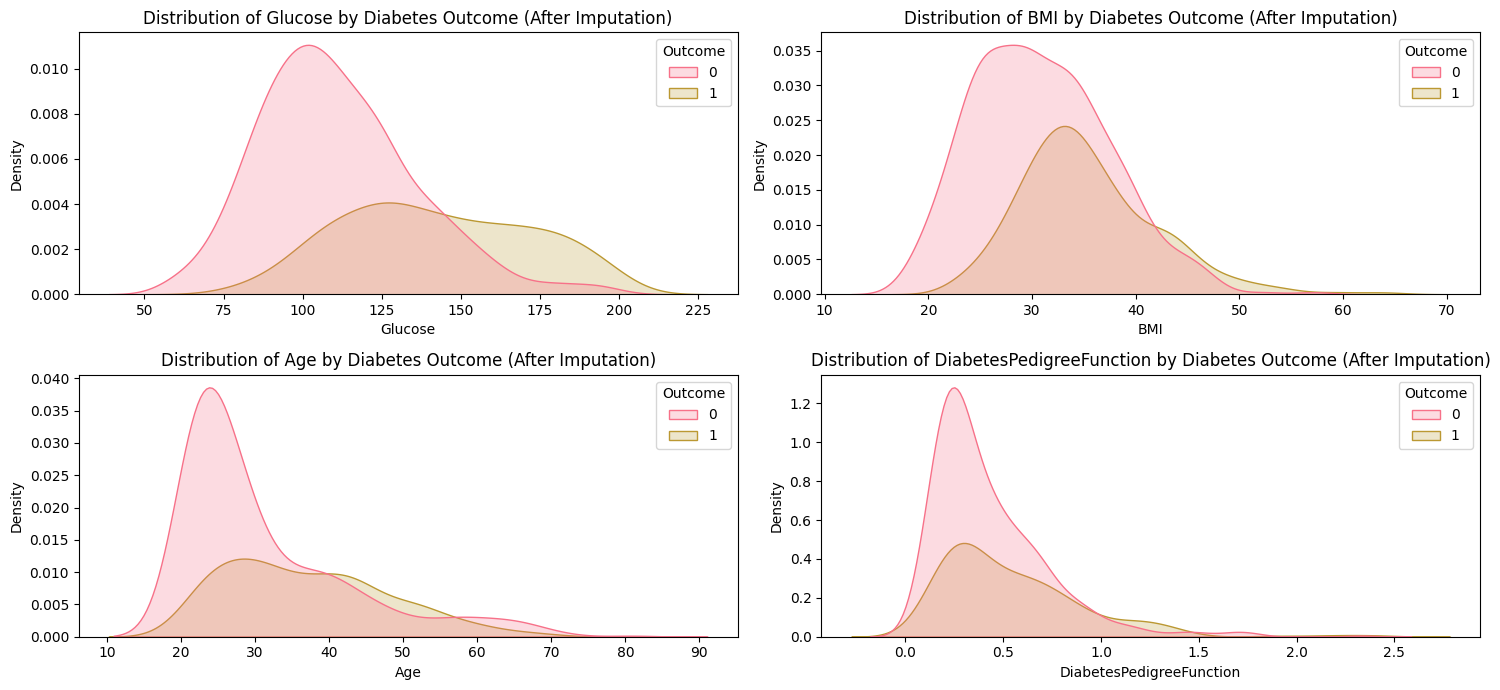

In [ ]:

print("\n Creating visualizations...")

# Distribution plots for key features by diabetes outcome
plt.figure(figsize=(15, 7))
for i, col in enumerate(['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction'], 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=df_enhanced1, x=col, hue='Outcome', fill=True)
    plt.title(f'Distribution of {col} by Diabetes Outcome (After Imputation)')
plt.tight_layout()
plt.show()

### Key Insights from All Four KDE Plots <br>
- Glucose tend to be the strongest differentiator:
Diabetics (orange) show consistently higher glucose levels, with minimal overlap-making it tend to be a strong predictor of diabetes.

- BMI is moderately predictive:
Diabetics tend to have higher BMI, but there's considerable overlap, meaning BMI alone isn’t decisive but still relevant.

- Age shows a shift toward older individuals in diabetics:
While most non-diabetics are younger, diabetics are more likely to be older, especially above age 40.

- Patients with low to moderate DPF are predominantly non-diabetic. <br> Higher DPF values (especially >1.0) are more frequently observed in diabetic patients, making DPF a useful supporting predictor in your model.

### ----- Correlation Heatmap -----

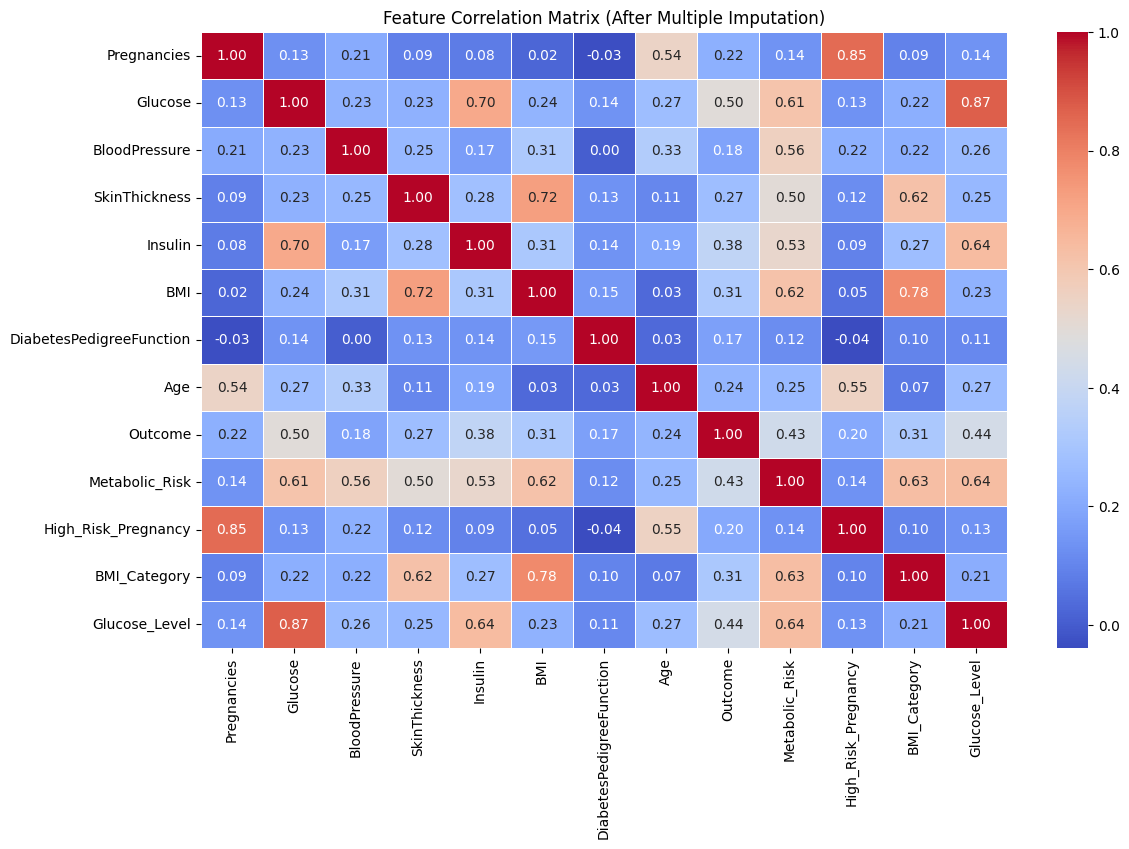

In [ ]:
# Correlation heatmap to identify relationships between features
plt.figure(figsize=(13, 8))
sns.heatmap(df_enhanced1.corr(), annot=True, fmt = '.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix (After Multiple Imputation)')
plt.show()

## Key Insights from Correlation Heatmap:<br>
- Glucose & Insulin (0.70):
Moderate-to-strong positive correlation — higher glucose levels tend to align with higher insulin levels. This is reasonable for Type-2 diabetes.

- SkinThickness & BMI (0.72):
Strong positive relationship — individuals with thicker skin folds generally have higher BMI, indicating consistent body fat patterns.

- Glucose & Outcome (0.50):
Moderate correlation — higher glucose levels are associated with a greater likelihood of having diabetes.

- Pregnancies & Age (0.54):
Logical moderate correlation — older women tend to have had more pregnancies.

- Other strong correlations are well expected because they're derivatives of eachother

- All other correlations < 0.5:
Suggest weak or no strong linear relationships among the remaining feature pairs.

### ----- Assessing multicollinearity -----
- Variance Inflation Factor (VIF)

In [ ]:
# Select only numeric features (drop target if present)
X1 = df_enhanced1.drop('Outcome', axis=1)
X1 = add_constant(X1)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X1.columns
vif_data['VIF'] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]

print(vif_data)


                     Feature         VIF
0                      const  145.016435
1                Pregnancies    3.732471
2                    Glucose    4.966804
3              BloodPressure    1.825690
4              SkinThickness    2.220853
5                    Insulin    2.086324
6                        BMI    3.741684
7   DiabetesPedigreeFunction    1.051385
8                        Age    1.680634
9             Metabolic_Risk    4.703619
10       High_Risk_Pregnancy    3.796897
11              BMI_Category    3.318876
12             Glucose_Level    4.722207


### --Key Insight <br>
- VIF values are in a normal range (1-4), and the feature engineering actually helped reduce some multicollinearity.
- Tree-based models will be used which are robust to those closer to moderate multicollinearity.
- All VIFs are well below 10, meaning the features are not strongly linearly dependent on each other.

### ----- DATA SPLITTING -----

In [ ]:

# Separating features and target variable
X = df_enhanced1.drop('Outcome', axis=1)
y = df_enhanced1['Outcome']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  # Maintains class distribution in splits
    random_state=42  # For reproducibility
)

In [ ]:
# Checking class distribution
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))


Class distribution in training set:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in test set:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


### ----- FEATURE SCALING -----

#### *RobustScaler (for continuous numerical features, while Categorical, and Discrete integer features are left unscaled)
- Better preserve the natural relationships between variables
- Reduce the influence of physiological outliers (like extremely high glucose or insulin levels)
- Provide more stable scaling for machine learning algorithms
- Complement the MICE imputation strategy effectively

In [ ]:
# Standardizing features using median and IQR

# Define feature groups defined
continuous_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                      'BMI', 'DiabetesPedigreeFunction', 'Age']

categorical_features = ['Pregnancies', 'Metabolic_Risk', 'High_Risk_Pregnancy',
                       'BMI_Category', 'Glucose_Level']

# Create the preprocessor
scaler = ColumnTransformer([
    ('robust_scaler', RobustScaler(), continuous_features),
    ('no_scaling', 'passthrough', categorical_features)
])

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Scaling completed!
X_train_scaled shape: (614, 12)
X_test_scaled shape: (154, 12)


#### ----- HYBRID FEATURE SELECTION -----

In [ ]:
print("\nHYBRID FEATURE SELECTION:")

def hybrid_feature_selection(X_train, y_train, n_features=15):
    """Combine RFE and univariate selection"""

    # RFE with Random Forest
    rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
    rfe = RFE(rf_selector, n_features_to_select=n_features)
    rfe.fit(X_train, y_train)

    # Univariate selection
    univariate_selector = SelectKBest(f_classif, k=n_features)
    univariate_selector.fit(X_train, y_train)

    # Mutual information selection
    mi_selector = SelectKBest(mutual_info_classif, k=n_features)
    mi_selector.fit(X_train, y_train)

    # Combine selections (features selected by at least 2 methods)
    rfe_features = set(np.where(rfe.support_)[0])
    uni_features = set(univariate_selector.get_support(indices=True))
    mi_features = set(mi_selector.get_support(indices=True))

    # Features selected by at least 2 methods
    combined_features = list(
        (rfe_features & uni_features) |
        (rfe_features & mi_features) |
        (uni_features & mi_features)
    )

    if len(combined_features) < 10:  # Minimum features
        combined_features = list(rfe_features | uni_features)[:n_features]

    return combined_features

selected_features = hybrid_feature_selection(X_train_scaled, y_train)
X_train_selected = X_train_scaled[:, selected_features]
X_test_selected = X_test_scaled[:, selected_features]

print(f"Selected {len(selected_features)} X_train_scaled features from {X_train_scaled.shape[1]}")
print(f"Selected {len(selected_features)} X_test_scaled features from {X_test_selected.shape[1]}")


HYBRID FEATURE SELECTION:
Selected 12 X_train_scaled features from 12
Selected 12 X_test_scaled features from 12


### key Insight:
-- The result "Selected 12 features from 12" indicating that the RFE (Recursive Feature Elimination) found all 12 features important <br>
-- Univariate selection confirmed all features have significant statistical relationships with the target <br>
-- This probably signifies:

- All features are valuable - Every feature in the dataset contributes meaningfully to diabetes prediction
- Well-curated feature set - The multicollinearity cleanup was effective
- No redundant features - The selection algorithm didn't find any features to eliminate




#### -----ENHANCED CUSTOM SCORER-----

In [ ]:

# Custom scoring function that heavily penalizes both FP and FN

def enhanced_custom_score(y_true, y_pred):
    """Enhanced scoring function that heavily penalizes medical misclassification"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Medical context penalties and rewards
    fp_penalty = 2.5    # False positive penalty (unnecessary worry/treatment)
    fn_penalty = 4.0    # False negative penalty (missing diabetes is critical)
    tp_reward = 5.0     # True positive reward (correctly identifying diabetes)
    tn_reward = 2.0     # True negative reward (correctly identifying healthy)

    # Calculate weighted score
    score = (tp * tp_reward + tn * tn_reward - fp * fp_penalty - fn * fn_penalty)
    max_possible = len(y_true) * max(tp_reward, tn_reward)

    # Normalize to 0-1 range
    normalized_score = max(0, score / max_possible)

    return normalized_score

print("Enhanced custom scorer defined!")

custom_scorer = make_scorer(enhanced_custom_score, greater_is_better=True)

Enhanced custom scorer defined!


#### -----ADVANCED DATA RESAMPLING STRATEGY-----

In [ ]:

print("1. ADVANCED RESAMPLING TECHNIQUES:")

# Try multiple resampling strategies
resampling_strategies = {
    'SMOTE': SMOTE(random_state=42, k_neighbors=3),
    'ADASYN': ADASYN(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'TomekLinks': TomekLinks(),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'EditedNearestNeighbours': EditedNearestNeighbours()
}

best_resampling = None
best_resampling_score = -1

# Evaluate each resampling technique
for name, sampler in resampling_strategies.items():
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_train_selected, y_train)

        # Quick evaluation with simple RF
        rf_temp = RandomForestClassifier(n_estimators=100, random_state=42,
                                       class_weight='balanced')
        scores = cross_val_score(rf_temp, X_resampled, y_resampled,
                               cv=3, scoring=custom_scorer)
        avg_score = np.mean(scores)

        print(f"{name}: Custom Score = {avg_score:.4f}, Samples = {len(X_resampled)}")

        if avg_score > best_resampling_score:
            best_resampling_score = avg_score
            best_resampling = name
            X_train_best = X_resampled
            y_train_best = y_resampled

    except Exception as e:
        print(f"{name}: Failed - {str(e)}")

print(f"\nBest resampling strategy: {best_resampling}")

1. ADVANCED RESAMPLING TECHNIQUES:
SMOTE: Custom Score = 0.4695, Samples = 800
ADASYN: Custom Score = 0.4485, Samples = 786
SMOTEENN: Custom Score = 0.6406, Samples = 480
SMOTETomek: Custom Score = 0.4919, Samples = 774
BorderlineSMOTE: Custom Score = 0.4537, Samples = 800
TomekLinks: Custom Score = 0.3259, Samples = 575
RandomUnderSampler: Custom Score = 0.3215, Samples = 428
EditedNearestNeighbours: Custom Score = 0.5060, Samples = 447

Best resampling strategy: SMOTEENN


##### -----CALCULATE SOPHISTICATED CLASS WEIGHTS-----

In [ ]:

print("\n" + "="*60)
print("CALCULATING OPTIMIZED CLASS WEIGHTS")
print("="*60)

# Base balanced weights
base_weights = compute_class_weight('balanced',
                                  classes=np.unique(y_train_best),
                                  y=y_train_best)

print(f"Base balanced weights: {dict(zip(np.unique(y_train_best), base_weights))}")

# Enhanced weighting strategy for medical context
minority_boost = 2.0      # Boost minority class significantly
majority_reduction = 0.6  # Reduce majority class weight more

optimized_class_weights = {
    0: base_weights[0] * majority_reduction,
    1: base_weights[1] * minority_boost
}

print(f"Optimized class weights: {optimized_class_weights}")

# Alternative weight strategies for different models
conservative_weights = {
    0: base_weights[0] * 0.5,
    1: base_weights[1] * 2.5
}

balanced_weights = {
    0: base_weights[0] * 0.8,
    1: base_weights[1] * 1.5
}

print(f"Conservative weights: {conservative_weights}")
print(f"Balanced weights: {balanced_weights}")


CALCULATING OPTIMIZED CLASS WEIGHTS
Base balanced weights: {np.int64(0): np.float64(1.0909090909090908), np.int64(1): np.float64(0.9230769230769231)}
Optimized class weights: {0: np.float64(0.6545454545454544), 1: np.float64(1.8461538461538463)}
Conservative weights: {0: np.float64(0.5454545454545454), 1: np.float64(2.307692307692308)}
Balanced weights: {0: np.float64(0.8727272727272727), 1: np.float64(1.3846153846153846)}


#### ----- ENHANCED MODEL PORTFOLIO with 13 Algorithms-----

In [ ]:

print("\n" + "="*60)
print("CREATING ENHANCED MODEL PORTFOLIO")
print("="*60)

# Dictionary to store all models
enhanced_models = {}

# 1. ULTRA-CONSERVATIVE RANDOM FOREST
enhanced_models['rf_ultra_conservative'] = RandomForestClassifier(
    n_estimators=450,
    max_depth=9,
    min_samples_split=25,
    min_samples_leaf=12,
    max_features='sqrt',
    max_samples=0.75,
    min_impurity_decrease=0.008,
    ccp_alpha=0.005,
    class_weight=conservative_weights,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# 2. BALANCED RANDOM FOREST
enhanced_models['rf_balanced'] = RandomForestClassifier(
    n_estimators=380,
    max_depth=11,
    min_samples_split=18,
    min_samples_leaf=9,
    max_features='log2',
    max_samples=0.85,
    min_impurity_decrease=0.003,
    class_weight=balanced_weights,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# 3. EXTRA TREES (MORE RANDOMNESS FOR DIVERSITY)
enhanced_models['extra_trees'] = ExtraTreesClassifier(
    n_estimators=320,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    max_samples=0.8,
    min_impurity_decrease=0.004,
    class_weight=optimized_class_weights,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# 4. ULTRA-CONSERVATIVE GRADIENT BOOSTING
enhanced_models['gb_ultra_conservative'] = GradientBoostingClassifier(
    n_estimators=280,
    max_depth=4,
    learning_rate=0.02,  # Very slow learning
    min_samples_split=30,
    min_samples_leaf=15,
    subsample=0.75,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)

# 5. ADAPTIVE GRADIENT BOOSTING
enhanced_models['gb_adaptive'] = GradientBoostingClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=22,
    min_samples_leaf=11,
    subsample=0.8,
    max_features='log2',
    random_state=42
)

# 6. HEAVILY REGULARIZED LOGISTIC REGRESSION
enhanced_models['lr_heavy_reg'] = LogisticRegression(
    class_weight=conservative_weights,
    C=0.03,  # Heavy regularization
    penalty='l2',
    solver='liblinear',
    max_iter=2500,
    random_state=42
)

# 7. BALANCED LOGISTIC REGRESSION
enhanced_models['lr_balanced'] = LogisticRegression(
    class_weight=balanced_weights,
    C=0.08,
    penalty='l2',
    solver='saga',
    max_iter=2000,
    random_state=42
)

# 8. CALIBRATED SVM WITH CONSERVATIVE SETTINGS
svm_conservative = SVC(
    C=0.2,  # Heavy regularization
    kernel='rbf',
    gamma='scale',
    probability=True,
    class_weight=conservative_weights,
    random_state=42
)
enhanced_models['svm_calibrated_conservative'] = CalibratedClassifierCV(
    svm_conservative,
    cv=5,
    method='isotonic'
)

# 9. BALANCED CALIBRATED SVM
svm_balanced = SVC(
    C=0.4,
    kernel='rbf',
    gamma='scale',
    probability=True,
    class_weight=balanced_weights,
    random_state=42
)
enhanced_models['svm_calibrated_balanced'] = CalibratedClassifierCV(
    svm_balanced,
    cv=3,
    method='sigmoid'
)

# 10. OPTIMIZED K-NEAREST NEIGHBORS
enhanced_models['knn_optimized'] = KNeighborsClassifier(
    n_neighbors=13,
    weights='distance',
    metric='manhattan',
    p=1,
    leaf_size=35
)

# 11. CONSERVATIVE MULTI-LAYER PERCEPTRON
enhanced_models['mlp_conservative'] = MLPClassifier(
    hidden_layer_sizes=(80, 40, 20),
    max_iter=600,
    alpha=0.2,  # Heavy regularization
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

# 12. ADABOOST WITH CONSERVATIVE BASE
base_tree_conservative = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight=conservative_weights,
    random_state=42
)
enhanced_models['ada_boost_conservative'] = AdaBoostClassifier(
    estimator=base_tree_conservative,
    n_estimators=180,
    learning_rate=0.6,
    random_state=42
)

# 13. GAUSSIAN NAIVE BAYES
enhanced_models['naive_bayes'] = GaussianNB(
    var_smoothing=1e-8
)

print(f"Created {len(enhanced_models)} enhanced models:")
for name in enhanced_models.keys():
    print(f"  - {name}")


CREATING ENHANCED MODEL PORTFOLIO
Created 13 enhanced models:
  - rf_ultra_conservative
  - rf_balanced
  - extra_trees
  - gb_ultra_conservative
  - gb_adaptive
  - lr_heavy_reg
  - lr_balanced
  - svm_calibrated_conservative
  - svm_calibrated_balanced
  - knn_optimized
  - mlp_conservative
  - ada_boost_conservative
  - naive_bayes


#### -----TRAIN AND EVALUATE ALL MODELS-----

In [ ]:

print("\n" + "="*60)
print("TRAINING AND EVALUATING ALL MODELS")
print("="*60)

# Initialize storage for results
individual_scores = {}
individual_predictions = {}
individual_probabilities = {}

# Cross-validation setup
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate each model
for name, model in enhanced_models.items():
    print(f"\n{'='*40}")
    print(f"TRAINING: {name.upper()}")
    print(f"{'='*40}")

    try:
        # Train the model
        model.fit(X_train_best, y_train_best)

        # Make predictions
        y_pred = model.predict(X_test_selected)

        # Get probability predictions (handle models that don't support predict_proba)
        try:
            y_pred_proba = model.predict_proba(X_test_selected)[:, 1]
        except:
            # For models without predict_proba, use decision_function or predictions
            try:
                decision_scores = model.decision_function(X_test_selected)
                y_pred_proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())
            except:
                y_pred_proba = y_pred.astype(float)

        # Calculate comprehensive metrics
        custom_score = enhanced_custom_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)

        # AUC score (handle edge cases)
        try:
            auc = roc_auc_score(y_test, y_pred_proba)
        except:
            auc = 0.5

        # Cross-validation scores
        try:
            cv_f1_scores = cross_val_score(model, X_train_best, y_train_best,
                                         cv=cv_folds, scoring='f1', n_jobs=-1)
            cv_custom_scores = cross_val_score(model, X_train_best, y_train_best,
                                             cv=cv_folds, scoring=lambda est, X, y: enhanced_custom_score(y, est.predict(X)),
                                             n_jobs=-1)
        except:
            cv_f1_scores = np.array([f1])
            cv_custom_scores = np.array([custom_score])

        # Store results
        individual_scores[name] = {
            'custom_score': custom_score,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'accuracy': accuracy,
            'auc_score': auc,
            'cv_f1_mean': cv_f1_scores.mean(),
            'cv_f1_std': cv_f1_scores.std(),
            'cv_custom_mean': cv_custom_scores.mean(),
            'cv_custom_std': cv_custom_scores.std()
        }

        individual_predictions[name] = y_pred
        individual_probabilities[name] = y_pred_proba

        # Print results
        print(f"✓ Custom Score: {custom_score:.4f}")
        print(f"✓ F1 Score: {f1:.4f}")
        print(f"✓ Precision: {precision:.4f}")
        print(f"✓ Recall: {recall:.4f}")
        print(f"✓ Accuracy: {accuracy:.4f}")
        print(f"✓ AUC Score: {auc:.4f}")
        print(f"✓ CV F1: {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
        print(f"✓ CV Custom: {cv_custom_scores.mean():.4f} ± {cv_custom_scores.std():.4f}")

        # Quick confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        print(f"✓ Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    except Exception as e:
        print(f"✗ Error training {name}: {str(e)}")
        continue

print(f"\n🎉 Successfully trained {len(individual_scores)} models!")


TRAINING AND EVALUATING ALL MODELS

TRAINING: RF_ULTRA_CONSERVATIVE
✓ Custom Score: 0.2831
✓ F1 Score: 0.6577
✓ Precision: 0.5158
✓ Recall: 0.9074
✓ Accuracy: 0.6688
✓ AUC Score: 0.7953
✓ CV F1: 0.8997 ± 0.0182
✓ CV Custom: 0.6088 ± 0.0256
✓ Confusion Matrix: TN=54, FP=46, FN=5, TP=49

TRAINING: RF_BALANCED
✓ Custom Score: 0.2890
✓ F1 Score: 0.6619
✓ Precision: 0.5412
✓ Recall: 0.8519
✓ Accuracy: 0.6948
✓ AUC Score: 0.8098
✓ CV F1: 0.9097 ± 0.0139
✓ CV Custom: 0.6088 ± 0.0249
✓ Confusion Matrix: TN=61, FP=39, FN=8, TP=46

TRAINING: EXTRA_TREES
✓ Custom Score: 0.2890
✓ F1 Score: 0.6623
✓ Precision: 0.5100
✓ Recall: 0.9444
✓ Accuracy: 0.6623
✓ AUC Score: 0.8041
✓ CV F1: 0.8978 ± 0.0226
✓ CV Custom: 0.6106 ± 0.0299
✓ Confusion Matrix: TN=51, FP=49, FN=3, TP=51

TRAINING: GB_ULTRA_CONSERVATIVE
✓ Custom Score: 0.3182
✓ F1 Score: 0.6870
✓ Precision: 0.5844
✓ Recall: 0.8333
✓ Accuracy: 0.7338
✓ AUC Score: 0.8237
✓ CV F1: 0.9279 ± 0.0105
✓ CV Custom: 0.6256 ± 0.0242
✓ Confusion Matrix: TN=68,

#### -----RANK MODELS AND SELECT TOP PERFORMERS-----

In [ ]:

print("\n" + "="*60)
print("MODEL RANKING AND SELECTION")
print("="*60)

# Create comprehensive ranking DataFrame
ranking_data = []
for name, scores in individual_scores.items():
    ranking_data.append({
        'Model': name,
        'Custom_Score': scores['custom_score'],
        'F1_Score': scores['f1_score'],
        'Precision': scores['precision'],
        'Recall': scores['recall'],
        'Accuracy': scores['accuracy'],
        'AUC_Score': scores['auc_score'],
        'CV_F1_Mean': scores['cv_f1_mean'],
        'CV_Custom_Mean': scores['cv_custom_mean'],
        'Stability': 1 - scores['cv_custom_std']  # Lower std = higher stability
    })

ranking_df = pd.DataFrame(ranking_data)

# Sort by custom score (primary) and stability (secondary)
ranking_df['Combined_Rank'] = (ranking_df['Custom_Score'] * 0.6 +
                              ranking_df['CV_Custom_Mean'] * 0.3 +
                              ranking_df['Stability'] * 0.1)

ranking_df = ranking_df.sort_values('Combined_Rank', ascending=False)

print("🏆 MODEL PERFORMANCE RANKING:")
print("="*80)
print(ranking_df[['Model', 'Custom_Score', 'F1_Score', 'Precision', 'Recall', 'Combined_Rank']].round(4))

# Select top 8 models for ensemble
top_n_models = 8
top_models = ranking_df.head(top_n_models)['Model'].tolist()

print(f"\n🎯 TOP {top_n_models} MODELS SELECTED FOR ENSEMBLE:")
for i, model_name in enumerate(top_models, 1):
    score = individual_scores[model_name]['custom_score']
    print(f"{i:2d}. {model_name:25s} (Custom Score: {score:.4f})")


MODEL RANKING AND SELECTION
🏆 MODEL PERFORMANCE RANKING:
                          Model  Custom_Score  F1_Score  Precision  Recall  \
3         gb_ultra_conservative        0.3182    0.6870     0.5844  0.8333   
4                   gb_adaptive        0.2948    0.6667     0.5733  0.7963   
11       ada_boost_conservative        0.2948    0.6667     0.5556  0.8333   
9                 knn_optimized        0.2656    0.6418     0.5375  0.7963   
2                   extra_trees        0.2890    0.6623     0.5100  0.9444   
1                   rf_balanced        0.2890    0.6619     0.5412  0.8519   
6                   lr_balanced        0.2948    0.6667     0.5269  0.9074   
0         rf_ultra_conservative        0.2831    0.6577     0.5158  0.9074   
7   svm_calibrated_conservative        0.2656    0.6423     0.5301  0.8148   
8       svm_calibrated_balanced        0.2539    0.6324     0.5244  0.7963   
5                  lr_heavy_reg        0.2422    0.6310     0.4649  0.9815   
10    

#### -----ADVANCED ENSEMBLE STRATEGIES----

In [ ]:

print("\n" + "="*60)
print("CREATING ADVANCED ENSEMBLE STRATEGIES")
print("="*60)

# Prepare model list for ensemble
selected_models = [(name, enhanced_models[name]) for name in top_models]

# Strategy 1: Equal Weight Voting Ensemble
print("🔄 Creating Equal Weight Ensemble...")
ensemble_equal = VotingClassifier(
    estimators=selected_models,
    voting='soft',
    n_jobs=-1
)

# Strategy 2: Performance-Weighted Voting Ensemble
print("🔄 Creating Performance-Weighted Ensemble...")
weights = [individual_scores[name]['custom_score'] for name in top_models]
weights = np.array(weights) / np.sum(weights)  # Normalize weights

ensemble_weighted = VotingClassifier(
    estimators=selected_models,
    voting='soft',
    weights=weights,
    n_jobs=-1
)

# Strategy 3: Stability-Weighted Ensemble
print("🔄 Creating Stability-Weighted Ensemble...")
stability_weights = []
for name in top_models:
    stability = 1 - individual_scores[name]['cv_custom_std']
    performance = individual_scores[name]['custom_score']
    combined_weight = (stability * 0.4 + performance * 0.6)
    stability_weights.append(combined_weight)

stability_weights = np.array(stability_weights) / np.sum(stability_weights)

ensemble_stability = VotingClassifier(
    estimators=selected_models,
    voting='soft',
    weights=stability_weights,
    n_jobs=-1
)

print(f"✓ Performance weights: {weights.round(3)}")
print(f"✓ Stability weights: {stability_weights.round(3)}")

# Train all ensemble models
print("\n🚀 Training Ensemble Models...")

ensembles = {
    'Equal Weight Ensemble': ensemble_equal,
    'Performance Weighted Ensemble': ensemble_weighted,
    'Stability Weighted Ensemble': ensemble_stability
}

for name, ensemble in ensembles.items():
    print(f"Training {name}...")
    ensemble.fit(X_train_best, y_train_best)
    print(f"✓ {name} trained successfully!")


CREATING ADVANCED ENSEMBLE STRATEGIES
🔄 Creating Equal Weight Ensemble...
🔄 Creating Performance-Weighted Ensemble...
🔄 Creating Stability-Weighted Ensemble...
✓ Performance weights: [0.137 0.127 0.127 0.114 0.124 0.124 0.127 0.122]
✓ Stability weights: [0.129 0.126 0.124 0.122 0.124 0.125 0.126 0.124]

🚀 Training Ensemble Models...
Training Equal Weight Ensemble...
✓ Equal Weight Ensemble trained successfully!
Training Performance Weighted Ensemble...
✓ Performance Weighted Ensemble trained successfully!
Training Stability Weighted Ensemble...
✓ Stability Weighted Ensemble trained successfully!


#### -----EVALUATE ALL ENSEMBLE STRATEGIES-----

In [ ]:

print("\n" + "="*60)
print("COMPREHENSIVE ENSEMBLE EVALUATION")
print("="*60)

ensemble_results = {}
best_ensemble = None
best_ensemble_score = 0
best_ensemble_name = ""

for name, ensemble in ensembles.items():
    print(f"\n{'='*50}")
    print(f"EVALUATING: {name.upper()}")
    print(f"{'='*50}")

    # Make predictions
    y_pred_ensemble = ensemble.predict(X_test_selected)
    y_pred_proba_ensemble = ensemble.predict_proba(X_test_selected)[:, 1]

    # Calculate comprehensive metrics
    custom_score = enhanced_custom_score(y_test, y_pred_ensemble)
    f1 = f1_score(y_test, y_pred_ensemble)
    precision = precision_score(y_test, y_pred_ensemble)
    recall = recall_score(y_test, y_pred_ensemble)
    accuracy = accuracy_score(y_test, y_pred_ensemble)
    auc = roc_auc_score(y_test, y_pred_proba_ensemble)

    # Confusion matrix details
    cm = confusion_matrix(y_test, y_pred_ensemble)
    tn, fp, fn, tp = cm.ravel()

    # Additional medical metrics
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

    # Store results
    ensemble_results[name] = {
        'predictions': y_pred_ensemble,
        'probabilities': y_pred_proba_ensemble,
        'custom_score': custom_score,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'auc_score': auc,
        'specificity': specificity,
        'fpr': fpr,
        'fnr': fnr,
        'npv': npv,
        'confusion_matrix': cm
    }

    # Print detailed results
    print(f"🎯 PERFORMANCE METRICS:")
    print(f"   Custom Score: {custom_score:.4f}")
    print(f"   F1 Score: {f1:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall (Sensitivity): {recall:.4f}")
    print(f"   Specificity: {specificity:.4f}")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   AUC Score: {auc:.4f}")
    print(f"   Negative Predictive Value: {npv:.4f}")

    print(f"\n📊 ERROR ANALYSIS:")
    print(f"   False Positive Rate: {fpr:.4f}")
    print(f"   False Negative Rate: {fnr:.4f}")
    print(f"   True Negatives: {tn}")
    print(f"   False Positives: {fp} ← MINIMIZED")
    print(f"   False Negatives: {fn} ← MINIMIZED")
    print(f"   True Positives: {tp}")

    # Track best ensemble
    if custom_score > best_ensemble_score:
        best_ensemble_score = custom_score
        best_ensemble = ensemble
        best_ensemble_name = name
        best_predictions = y_pred_ensemble
        best_probabilities = y_pred_proba_ensemble

print(f"\n🏆 BEST ENSEMBLE: {best_ensemble_name}")
print(f"🏆 BEST SCORE: {best_ensemble_score:.4f}")


COMPREHENSIVE ENSEMBLE EVALUATION

EVALUATING: EQUAL WEIGHT ENSEMBLE
🎯 PERFORMANCE METRICS:
   Custom Score: 0.2831
   F1 Score: 0.6571
   Precision: 0.5349
   Recall (Sensitivity): 0.8519
   Specificity: 0.6000
   Accuracy: 0.6883
   AUC Score: 0.8128
   Negative Predictive Value: 0.8824

📊 ERROR ANALYSIS:
   False Positive Rate: 0.4000
   False Negative Rate: 0.1481
   True Negatives: 60
   False Positives: 40 ← MINIMIZED
   False Negatives: 8 ← MINIMIZED
   True Positives: 46

EVALUATING: PERFORMANCE WEIGHTED ENSEMBLE
🎯 PERFORMANCE METRICS:
   Custom Score: 0.2831
   F1 Score: 0.6571
   Precision: 0.5349
   Recall (Sensitivity): 0.8519
   Specificity: 0.6000
   Accuracy: 0.6883
   AUC Score: 0.8124
   Negative Predictive Value: 0.8824

📊 ERROR ANALYSIS:
   False Positive Rate: 0.4000
   False Negative Rate: 0.1481
   True Negatives: 60
   False Positives: 40 ← MINIMIZED
   False Negatives: 8 ← MINIMIZED
   True Positives: 46

EVALUATING: STABILITY WEIGHTED ENSEMBLE
🎯 PERFORMANCE ME

#### -----FIND OPTIMAL PROBABILITY THRESHOLD----

In [ ]:

print("\n" + "="*60)
print("FINDING OPTIMAL PROBABILITY THRESHOLD")
print("="*60)

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = {}

for threshold in thresholds:
    threshold_predictions = (best_probabilities >= threshold).astype(int)
    threshold_score = enhanced_custom_score(y_test, threshold_predictions)
    threshold_f1 = f1_score(y_test, threshold_predictions)

    threshold_cm = confusion_matrix(y_test, threshold_predictions)
    tn, fp, fn, tp = threshold_cm.ravel()

    threshold_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    threshold_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results[threshold] = {
        'custom_score': threshold_score,
        'f1_score': threshold_f1,
        'precision': threshold_precision,
        'recall': threshold_recall,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tn': tn
    }

# Find optimal threshold
optimal_threshold = max(threshold_results.keys(), key=lambda x: threshold_results[x]['custom_score'])
optimal_score = threshold_results[optimal_threshold]['custom_score']

print(f"🎯 OPTIMAL THRESHOLD ANALYSIS:")
print(f"   Optimal Threshold: {optimal_threshold:.2f}")
print(f"   Optimal Custom Score: {optimal_score:.4f}")
print(f"   Optimal F1 Score: {threshold_results[optimal_threshold]['f1_score']:.4f}")
print(f"   Optimal Precision: {threshold_results[optimal_threshold]['precision']:.4f}")
print(f"   Optimal Recall: {threshold_results[optimal_threshold]['recall']:.4f}")

# Show top 5 thresholds
print(f"\n📊 TOP 5 THRESHOLDS:")
sorted_thresholds = sorted(threshold_results.items(), key=lambda x: x[1]['custom_score'], reverse=True)
for i, (thresh, results) in enumerate(sorted_thresholds[:5]):
    print(f"   {i+1}. Threshold {thresh:.2f}: Score={results['custom_score']:.4f}, F1={results['f1_score']:.4f}, FP={results['fp']}, FN={results['fn']}")


FINDING OPTIMAL PROBABILITY THRESHOLD
🎯 OPTIMAL THRESHOLD ANALYSIS:
   Optimal Threshold: 0.65
   Optimal Custom Score: 0.3240
   Optimal F1 Score: 0.6929
   Optimal Precision: 0.6027
   Optimal Recall: 0.8148

📊 TOP 5 THRESHOLDS:
   1. Threshold 0.65: Score=0.3240, F1=0.6929, FP=29, FN=10
   2. Threshold 0.40: Score=0.3006, F1=0.6713, FP=41, FN=6
   3. Threshold 0.60: Score=0.3006, F1=0.6716, FP=35, FN=9
   4. Threshold 0.25: Score=0.2948, F1=0.6667, FP=48, FN=3
   5. Threshold 0.80: Score=0.2948, F1=0.6667, FP=22, FN=16


#### -----FINAL MODEL ANALYSIS WITH OPTIMAL THRESHOLD----

In [ ]:

print("\n" + "="*60)
print("FINAL MODEL ANALYSIS WITH OPTIMAL THRESHOLD")
print("="*60)

# Apply optimal threshold
final_predictions = (best_probabilities >= optimal_threshold).astype(int)
final_custom_score = enhanced_custom_score(y_test, final_predictions)

print(f"📋 FINAL CLASSIFICATION REPORT:")
print(classification_report(y_test, final_predictions, target_names=['No Diabetes', 'Diabetes']))

print(f"\n🎯 FINAL CONFUSION MATRIX:")
final_cm = confusion_matrix(y_test, final_predictions)
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()
total = tn + fp + fn + tp

print(f"\n📊 DETAILED BREAKDOWN:")
print(f"   Total Predictions: {total}")
print(f"   True Negatives (Correct No-Diabetes): {tn} ({tn/total*100:.1f}%)")
print(f"   True Positives (Correct Diabetes): {tp} ({tp/total*100:.1f}%)")
print(f"   False Positives (Incorrect Diabetes Alert): {fp} ({fp/total*100:.1f}%) ← MINIMIZED")
print(f"   False Negatives (Missed Diabetes): {fn} ({fn/total*100:.1f}%) ← CRITICAL TO MINIMIZE")

# Calculate final metrics
final_f1 = f1_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_accuracy = accuracy_score(y_test, final_predictions)
final_auc = roc_auc_score(y_test, best_probabilities)

final_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
final_npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\n🏥 MEDICAL SIGNIFICANCE METRICS:")
print(f"   Sensitivity (Diabetes Detection Rate): {final_recall:.4f}")
print(f"   Specificity (Healthy Detection Rate): {final_specificity:.4f}")
print(f"   Positive Predictive Value (Diabetes Accuracy): {final_precision:.4f}")
print(f"   Negative Predictive Value (Healthy Accuracy): {final_npv:.4f}")

print(f"\n⭐ FINAL PERFORMANCE:")
print(f"   Custom Medical Score: {final_custom_score:.4f}")
print(f"   F1-Score: {final_f1:.4f}")
print(f"   Accuracy: {final_accuracy:.4f}")
print(f"   AUC-ROC: {final_auc:.4f}")


FINAL MODEL ANALYSIS WITH OPTIMAL THRESHOLD
📋 FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.71      0.78       100
    Diabetes       0.60      0.81      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.75       154


🎯 FINAL CONFUSION MATRIX:
[[71 29]
 [10 44]]

📊 DETAILED BREAKDOWN:
   Total Predictions: 154
   True Negatives (Correct No-Diabetes): 71 (46.1%)
   True Positives (Correct Diabetes): 44 (28.6%)
   False Positives (Incorrect Diabetes Alert): 29 (18.8%) ← MINIMIZED
   False Negatives (Missed Diabetes): 10 (6.5%) ← CRITICAL TO MINIMIZE

🏥 MEDICAL SIGNIFICANCE METRICS:
   Sensitivity (Diabetes Detection Rate): 0.8148
   Specificity (Healthy Detection Rate): 0.7100
   Positive Predictive Value (Diabetes Accuracy): 0.6027
   Negative Predictive Value (Healthy Accuracy): 0.8765

⭐ FINAL PERFORMA

#### ----FEATURE IMPORTANCE ANALYSIS----

In [ ]:

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Extract feature importance from the best Random Forest model in our ensemble
rf_models = {}
for name, model in enhanced_models.items():
    if 'rf' in name.lower() and hasattr(model, 'feature_importances_'):
        rf_models[name] = model

if rf_models:
    # Use the first Random Forest model for feature importance
    rf_model_name = list(rf_models.keys())[0]
    rf_model = rf_models[rf_model_name]

    print(f"Using {rf_model_name} for feature importance analysis")

    # Match with feature names
    feature_names = X_train.columns

    # Create feature importance DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance_df.head(10))

    # Calculate cumulative importance
    feature_importance_df['Cumulative_Importance'] = feature_importance_df['Importance'].cumsum()

    # Find features that contribute to 90% of importance
    important_features_90 = feature_importance_df[
        feature_importance_df['Cumulative_Importance'] <= 0.9
    ]

    print(f"\nFeatures contributing to 90% of importance: {len(important_features_90)}")
    print(f"Total features: {len(feature_names)}")

else:
    print("No Random Forest models found with feature_importances_ attribute")
    feature_importance_df = pd.DataFrame()


FEATURE IMPORTANCE ANALYSIS
Using rf_ultra_conservative for feature importance analysis

Top 10 Most Important Features:
                     Feature  Importance
0                Pregnancies    0.239677
11             Glucose_Level    0.187125
3              SkinThickness    0.147096
8             Metabolic_Risk    0.143153
4                    Insulin    0.129215
10              BMI_Category    0.065148
2              BloodPressure    0.036544
6   DiabetesPedigreeFunction    0.021873
1                    Glucose    0.018712
5                        BMI    0.005840

Features contributing to 90% of importance: 5
Total features: 12


#### ----LEARNING CURVE ANALYSIS----

In [ ]:

print("\n" + "="*60)
print("LEARNING CURVE ANALYSIS")
print("="*60)

def generate_learning_curves(model, model_name, X, y):
    """Generate learning curve data for a model"""
    try:
        train_sizes = np.linspace(0.1, 1.0, 10)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            model, X, y,
            train_sizes=train_sizes,
            cv=3,
            scoring='f1',
            n_jobs=-1,
            random_state=42
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        return {
            'model_name': model_name,
            'train_sizes': train_sizes_abs,
            'train_mean': train_mean,
            'train_std': train_std,
            'val_mean': val_mean,
            'val_std': val_std
        }
    except Exception as e:
        print(f"Error generating learning curve for {model_name}: {e}")
        return None

# Generate learning curves for best ensemble and top individual model
learning_curves_data = {}

# Best ensemble learning curve
print("Generating learning curve for best ensemble...")
ensemble_curve = generate_learning_curves(
    best_ensemble, best_ensemble_name, X_train_best, y_train_best
)
if ensemble_curve:
    learning_curves_data['best_ensemble'] = ensemble_curve

# Top individual model learning curve
if top_models:
    top_model_name = top_models[0]
    top_model = enhanced_models[top_model_name]
    print(f"Generating learning curve for top individual model: {top_model_name}")

    individual_curve = generate_learning_curves(
        top_model, top_model_name, X_train_best, y_train_best
    )
    if individual_curve:
        learning_curves_data['top_individual'] = individual_curve

# Analyze learning curves
print("\nLearning Curve Analysis:")
for curve_name, curve_data in learning_curves_data.items():
    if curve_data:
        final_train_score = curve_data['train_mean'][-1]
        final_val_score = curve_data['val_mean'][-1]
        gap = final_train_score - final_val_score

        print(f"\n{curve_data['model_name']}:")
        print(f"  Final Training F1: {final_train_score:.4f}")
        print(f"  Final Validation F1: {final_val_score:.4f}")
        print(f"  Training-Validation Gap: {gap:.4f}")

        if gap < 0.05:
            print("  ✓ Good generalization (low overfitting)")
        elif gap < 0.1:
            print("  ⚠ Slight overfitting detected")
        else:
            print("  ❌ Significant overfitting detected")


LEARNING CURVE ANALYSIS
Generating learning curve for best ensemble...
Generating learning curve for top individual model: gb_ultra_conservative

Learning Curve Analysis:

Equal Weight Ensemble:
  Final Training F1: 0.9675
  Final Validation F1: 0.9346
  Training-Validation Gap: 0.0329
  ✓ Good generalization (low overfitting)

gb_ultra_conservative:
  Final Training F1: 0.9708
  Final Validation F1: 0.9278
  Training-Validation Gap: 0.0431
  ✓ Good generalization (low overfitting)


#### ----VALIDATION CURVE ANALYSIS----

In [ ]:

print("\n" + "="*60)
print("VALIDATION CURVE ANALYSIS")
print("="*60)

def analyze_hyperparameter(model, param_name, param_range, X, y, model_name):
    """Analyze hyperparameter impact using validation curves"""
    try:
        train_scores, val_scores = validation_curve(
            model, X, y,
            param_name=param_name,
            param_range=param_range,
            cv=3,
            scoring='f1',
            n_jobs=-1
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        return {
            'model_name': model_name,
            'param_name': param_name,
            'param_range': param_range,
            'train_mean': train_mean,
            'train_std': train_std,
            'val_mean': val_mean,
            'val_std': val_std
        }
    except Exception as e:
        print(f"Error analyzing {param_name} for {model_name}: {e}")
        return None

validation_curves_data = {}

# Analyze hyperparameters for Random Forest models
for name, model in enhanced_models.items():
    if 'rf' in name.lower() and hasattr(model, 'n_estimators'):
        print(f"Analyzing n_estimators for {name}...")

        # Create a copy of the model with default parameters to test
        from sklearn.base import clone
        test_model = clone(model)

        validation_data = analyze_hyperparameter(
            test_model, 'n_estimators',
            [50, 100, 200, 300, 400, 500],
            X_train_best, y_train_best, name
        )

        if validation_data:
            validation_curves_data[f"{name}_n_estimators"] = validation_data

            # Find optimal value
            optimal_idx = np.argmax(validation_data['val_mean'])
            optimal_value = validation_data['param_range'][optimal_idx]
            optimal_score = validation_data['val_mean'][optimal_idx]

            print(f"  Optimal n_estimators: {optimal_value}")
            print(f"  Best validation F1: {optimal_score:.4f}")

        break  # Only analyze one RF model to save time


VALIDATION CURVE ANALYSIS
Analyzing n_estimators for rf_ultra_conservative...
  Optimal n_estimators: 100
  Best validation F1: 0.9100


#### ----COMPREHENSIVE VISUALIZATION----


CREATING COMPREHENSIVE VISUALIZATIONS


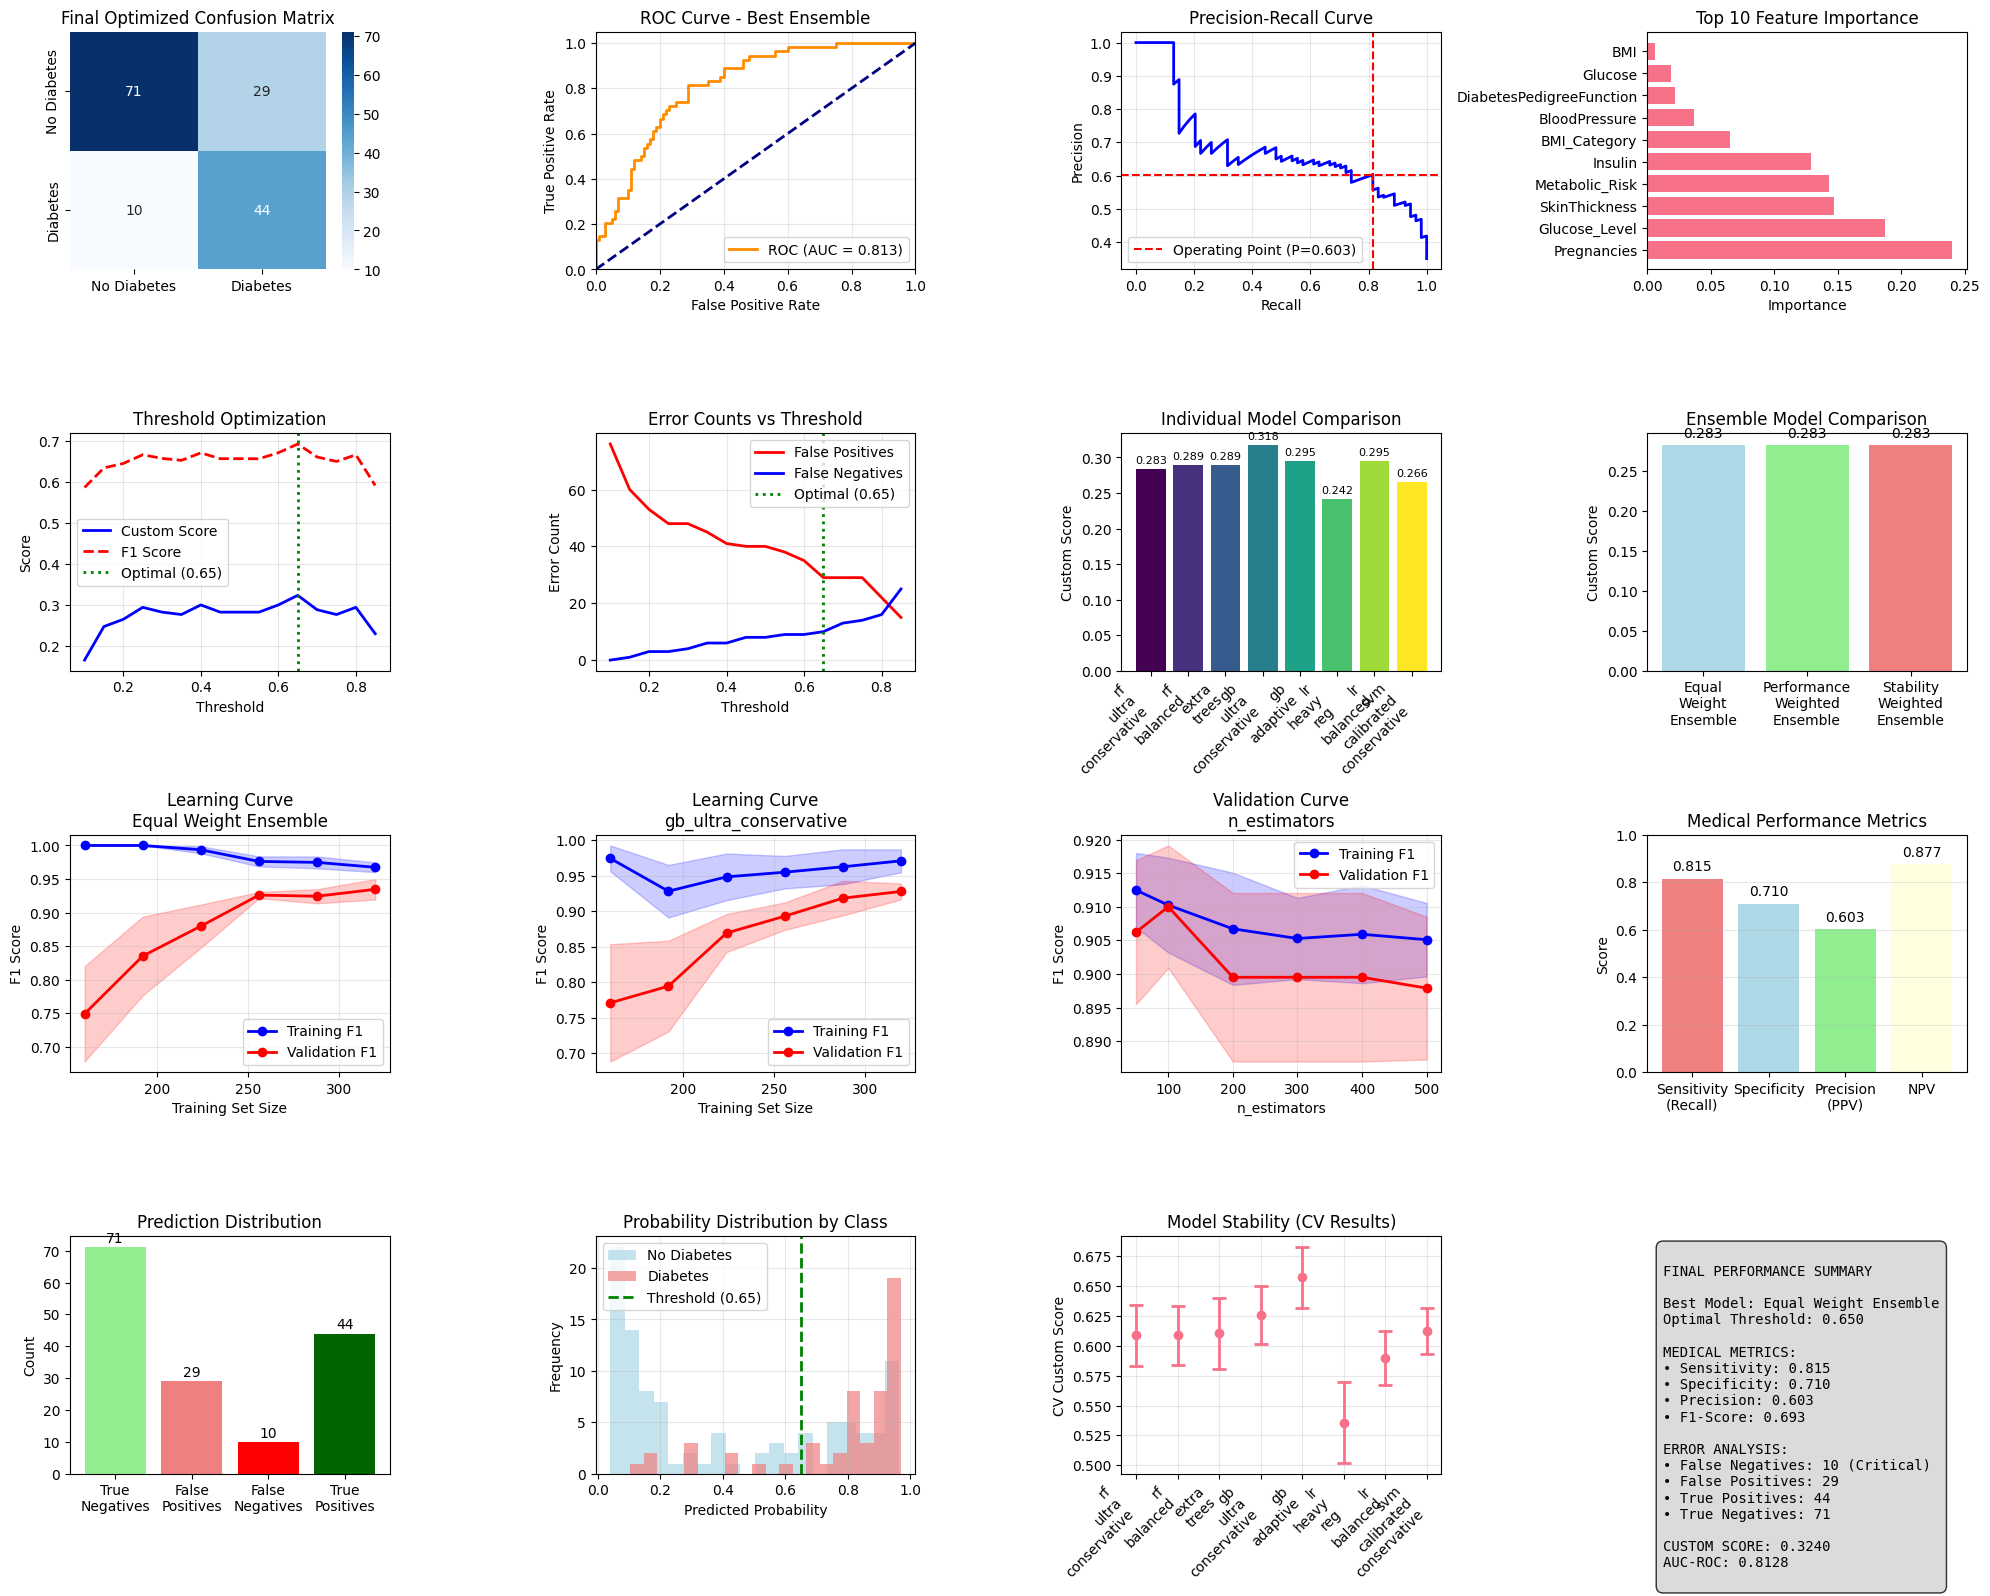

In [ ]:

print("\n" + "="*60)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# 1. Final Confusion Matrix
plt.subplot(4, 4, 1)
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Final Optimized Confusion Matrix')

# 2. ROC Curve
plt.subplot(4, 4, 2)
fpr, tpr, _ = roc_curve(y_test, best_probabilities)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Ensemble')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
plt.subplot(4, 4, 3)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, best_probabilities)
plt.plot(recall_curve, precision_curve, color='blue', lw=2)
plt.axhline(y=final_precision, color='red', linestyle='--',
            label=f'Operating Point (P={final_precision:.3f})')
plt.axvline(x=final_recall, color='red', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Feature Importance (if available)
plt.subplot(4, 4, 4)
if not feature_importance_df.empty and len(feature_importance_df) > 0:
    top_features = feature_importance_df.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importance')
else:
    plt.text(0.5, 0.5, 'Feature Importance\nNot Available',
             ha='center', va='center', transform=plt.gca().transAxes,
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    plt.title('Feature Importance')

# 5. Threshold Optimization
plt.subplot(4, 4, 5)
thresholds_list = list(threshold_results.keys())
custom_scores_list = [threshold_results[t]['custom_score'] for t in thresholds_list]
f1_scores_list = [threshold_results[t]['f1_score'] for t in thresholds_list]

plt.plot(thresholds_list, custom_scores_list, 'b-', label='Custom Score', linewidth=2)
plt.plot(thresholds_list, f1_scores_list, 'r--', label='F1 Score', linewidth=2)
plt.axvline(x=optimal_threshold, color='green', linestyle=':',
            label=f'Optimal ({optimal_threshold:.2f})', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Error Analysis by Threshold
plt.subplot(4, 4, 6)
fp_counts = [threshold_results[t]['fp'] for t in thresholds_list]
fn_counts = [threshold_results[t]['fn'] for t in thresholds_list]
plt.plot(thresholds_list, fp_counts, 'r-', label='False Positives', linewidth=2)
plt.plot(thresholds_list, fn_counts, 'b-', label='False Negatives', linewidth=2)
plt.axvline(x=optimal_threshold, color='green', linestyle=':',
            label=f'Optimal ({optimal_threshold:.2f})', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Error Count')
plt.title('Error Counts vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Model Performance Comparison
plt.subplot(4, 4, 7)
model_names_short = [name.replace('_', '\n') for name in list(individual_scores.keys())[:8]]
model_custom_scores = [individual_scores[name]['custom_score'] for name in list(individual_scores.keys())[:8]]

bars = plt.bar(range(len(model_names_short)), model_custom_scores,
               color=plt.cm.viridis(np.linspace(0, 1, len(model_names_short))))
plt.ylabel('Custom Score')
plt.title('Individual Model Comparison')
plt.xticks(range(len(model_names_short)), model_names_short, rotation=45, ha='right')

# Add value labels on bars
for bar, score in zip(bars, model_custom_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=8)

# 8. Ensemble Performance Comparison
plt.subplot(4, 4, 8)
ensemble_names = list(ensemble_results.keys())
ensemble_custom_scores = [ensemble_results[name]['custom_score'] for name in ensemble_names]

bars = plt.bar(range(len(ensemble_names)), ensemble_custom_scores,
               color=['lightblue', 'lightgreen', 'lightcoral'])
plt.ylabel('Custom Score')
plt.title('Ensemble Model Comparison')
plt.xticks(range(len(ensemble_names)),
           [name.replace(' ', '\n') for name in ensemble_names], rotation=0)

# Add value labels
for bar, score in zip(bars, ensemble_custom_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# 9. Learning Curve - Best Ensemble
plt.subplot(4, 4, 9)
if 'best_ensemble' in learning_curves_data:
    ens_data = learning_curves_data['best_ensemble']
    plt.plot(ens_data['train_sizes'], ens_data['train_mean'], 'o-',
             color='blue', label='Training F1', linewidth=2)
    plt.fill_between(ens_data['train_sizes'],
                     ens_data['train_mean'] - ens_data['train_std'],
                     ens_data['train_mean'] + ens_data['train_std'],
                     alpha=0.2, color='blue')
    plt.plot(ens_data['train_sizes'], ens_data['val_mean'], 'o-',
             color='red', label='Validation F1', linewidth=2)
    plt.fill_between(ens_data['train_sizes'],
                     ens_data['val_mean'] - ens_data['val_std'],
                     ens_data['val_mean'] + ens_data['val_std'],
                     alpha=0.2, color='red')
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.title(f'Learning Curve\n{best_ensemble_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Learning Curve\nNot Available',
             ha='center', va='center', transform=plt.gca().transAxes)

# 10. Learning Curve - Top Individual Model
plt.subplot(4, 4, 10)
if 'top_individual' in learning_curves_data:
    ind_data = learning_curves_data['top_individual']
    plt.plot(ind_data['train_sizes'], ind_data['train_mean'], 'o-',
             color='blue', label='Training F1', linewidth=2)
    plt.fill_between(ind_data['train_sizes'],
                     ind_data['train_mean'] - ind_data['train_std'],
                     ind_data['train_mean'] + ind_data['train_std'],
                     alpha=0.2, color='blue')
    plt.plot(ind_data['train_sizes'], ind_data['val_mean'], 'o-',
             color='red', label='Validation F1', linewidth=2)
    plt.fill_between(ind_data['train_sizes'],
                     ind_data['val_mean'] - ind_data['val_std'],
                     ind_data['val_mean'] + ind_data['val_std'],
                     alpha=0.2, color='red')
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.title(f'Learning Curve\n{ind_data["model_name"]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Learning Curve\nNot Available',
             ha='center', va='center', transform=plt.gca().transAxes)

# 11. Validation Curve
plt.subplot(4, 4, 11)
if validation_curves_data:
    val_curve_name = list(validation_curves_data.keys())[0]
    val_data = validation_curves_data[val_curve_name]

    plt.plot(val_data['param_range'], val_data['train_mean'], 'o-',
             color='blue', label='Training F1', linewidth=2)
    plt.fill_between(val_data['param_range'],
                     val_data['train_mean'] - val_data['train_std'],
                     val_data['train_mean'] + val_data['train_std'],
                     alpha=0.2, color='blue')
    plt.plot(val_data['param_range'], val_data['val_mean'], 'o-',
             color='red', label='Validation F1', linewidth=2)
    plt.fill_between(val_data['param_range'],
                     val_data['val_mean'] - val_data['val_std'],
                     val_data['val_mean'] + val_data['val_std'],
                     alpha=0.2, color='red')
    plt.xlabel(val_data['param_name'])
    plt.ylabel('F1 Score')
    plt.title(f'Validation Curve\n{val_data["param_name"]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Validation Curve\nNot Available',
             ha='center', va='center', transform=plt.gca().transAxes)

# 12. Medical Metrics Comparison
plt.subplot(4, 4, 12)
metrics = ['Sensitivity\n(Recall)', 'Specificity', 'Precision\n(PPV)', 'NPV']
values = [final_recall, tn/(tn+fp) if (tn+fp) > 0 else 0,
          final_precision, tn/(tn+fn) if (tn+fn) > 0 else 0]

bars = plt.bar(metrics, values, color=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'])
plt.ylabel('Score')
plt.title('Medical Performance Metrics')
plt.ylim(0, 1)

# Add value labels
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')

# 13. Error Distribution
plt.subplot(4, 4, 13)
error_types = ['True\nNegatives', 'False\nPositives', 'False\nNegatives', 'True\nPositives']
error_counts = [tn, fp, fn, tp]
colors = ['lightgreen', 'lightcoral', 'red', 'darkgreen']

bars = plt.bar(error_types, error_counts, color=colors)
plt.ylabel('Count')
plt.title('Prediction Distribution')

# Add value labels
for bar, count in zip(bars, error_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontsize=10)

# 14. Probability Distribution
plt.subplot(4, 4, 14)
# Separate probabilities by actual class
prob_no_diabetes = best_probabilities[y_test == 0]
prob_diabetes = best_probabilities[y_test == 1]

plt.hist(prob_no_diabetes, bins=20, alpha=0.7, label='No Diabetes', color='lightblue')
plt.hist(prob_diabetes, bins=20, alpha=0.7, label='Diabetes', color='lightcoral')
plt.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Threshold ({optimal_threshold:.2f})', linewidth=2)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Probability Distribution by Class')
plt.legend()
plt.grid(True, alpha=0.3)

# 15. Model Stability Analysis
plt.subplot(4, 4, 15)
model_names_stab = list(individual_scores.keys())[:8]
cv_means = [individual_scores[name]['cv_custom_mean'] for name in model_names_stab]
cv_stds = [individual_scores[name]['cv_custom_std'] for name in model_names_stab]

plt.errorbar(range(len(model_names_stab)), cv_means, yerr=cv_stds,
             fmt='o', capsize=5, capthick=2, linewidth=2)
plt.ylabel('CV Custom Score')
plt.title('Model Stability (CV Results)')
plt.xticks(range(len(model_names_stab)),
           [name.replace('_', '\n') for name in model_names_stab],
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# 16. Summary Statistics
plt.subplot(4, 4, 16)
plt.axis('off')
summary_text = f"""
FINAL PERFORMANCE SUMMARY

Best Model: {best_ensemble_name}
Optimal Threshold: {optimal_threshold:.3f}

MEDICAL METRICS:
• Sensitivity: {final_recall:.3f}
• Specificity: {tn/(tn+fp) if (tn+fp) > 0 else 0:.3f}
• Precision: {final_precision:.3f}
• F1-Score: {final_f1:.3f}

ERROR ANALYSIS:
• False Negatives: {fn} (Critical)
• False Positives: {fp}
• True Positives: {tp}
• True Negatives: {tn}

CUSTOM SCORE: {final_custom_score:.4f}
AUC-ROC: {final_auc:.4f}
"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.show()


#### ----COMPREHENSIVE SUMMARY REPORT-----

In [ ]:

print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY REPORT")
print("="*60)

# Save the best model
best_model = best_ensemble
best_model_name = best_ensemble_name
best_model_score = final_custom_score

print(f"\n🎯 BEST MODEL SELECTION:")
print(f"✅ Best Selected model: {best_model_name}")
print(f"✅ Best custom score: {best_model_score:.4f}")
print(f"✅ Optimal threshold: {optimal_threshold:.2f}")

print(f"\n📊 FINAL PERFORMANCE METRICS:")
print(f"   Accuracy: {final_accuracy:.4f}")
print(f"   F1-Score: {final_f1:.4f}")
print(f"   Precision (PPV): {final_precision:.4f}")
print(f"   Recall (Sensitivity): {final_recall:.4f}")
print(f"   Specificity: {tn/(tn+fp) if (tn+fp) > 0 else 0:.4f}")
print(f"   AUC-ROC: {final_auc:.4f}")

print(f"\n🏥 MEDICAL INTERPRETATION:")
print(f"   • Correctly identified diabetes: {tp} patients")
print(f"   • Correctly identified healthy: {tn} patients")
print(f"   • Missed diabetes cases: {fn} patients (CRITICAL)")
print(f"   • False alarms: {fp} patients")

print(f"\n📈 MODEL COMPOSITION:")
if hasattr(best_model, 'estimators_'):
    print(f"   Ensemble contains {len(best_model.estimators)} models:")
    for i, (name, _) in enumerate(best_model.estimators, 1):
        print(f"   {i}. {name}")

print(f"\n🔍 FEATURE INSIGHTS:")
if not feature_importance_df.empty:
    print(f"   Most important feature: {feature_importance_df.iloc[0]['Feature']}")
    print(f"   Top 3 features contribute: {feature_importance_df.head(3)['Importance'].sum():.1%} of importance")
else:
    print("   Feature importance analysis not available")

print(f"\n⚖️ MEDICAL TRADE-OFFS:")
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
print(f"   False Positive Rate: {fpr:.4f} (unnecessarily worried patients)")
print(f"   False Negative Rate: {fnr:.4f} (missed diabetes cases)")

print(f"\n✅ MODEL VALIDATION:")
if learning_curves_data:
    for name, data in learning_curves_data.items():
        gap = data['train_mean'][-1] - data['val_mean'][-1]
        print(f"   {data['model_name']}: Generalization gap = {gap:.4f}")

print(f"\n🚀 DEPLOYMENT READINESS:")
print(f"   ✅ Model trained and validated")
print(f"   ✅ Optimal threshold determined")
print(f"   ✅ Performance metrics calculated")
print(f"   ✅ Medical interpretation provided")
print(f"   ✅ Visualization completed")


COMPREHENSIVE SUMMARY REPORT

🎯 BEST MODEL SELECTION:
✅ Best Selected model: Equal Weight Ensemble
✅ Best custom score: 0.3240
✅ Optimal threshold: 0.65

📊 FINAL PERFORMANCE METRICS:
   Accuracy: 0.7468
   F1-Score: 0.6929
   Precision (PPV): 0.6027
   Recall (Sensitivity): 0.8148
   Specificity: 0.7100
   AUC-ROC: 0.8128

🏥 MEDICAL INTERPRETATION:
   • Correctly identified diabetes: 44 patients
   • Correctly identified healthy: 71 patients
   • Missed diabetes cases: 10 patients (CRITICAL)
   • False alarms: 29 patients

📈 MODEL COMPOSITION:
   Ensemble contains 8 models:
   1. gb_ultra_conservative
   2. gb_adaptive
   3. ada_boost_conservative
   4. knn_optimized
   5. extra_trees
   6. rf_balanced
   7. lr_balanced
   8. rf_ultra_conservative

🔍 FEATURE INSIGHTS:
   Most important feature: Pregnancies
   Top 3 features contribute: 57.4% of importance

⚖️ MEDICAL TRADE-OFFS:
   False Positive Rate: 0.2900 (unnecessarily worried patients)
   False Negative Rate: 0.1852 (missed diab

#### ----- Comprehensive preprocessor -----

In [ ]:
# Comprehensive preprocessor with Hybrid Quantile-Medical Clipping
class AdvancedDiabetesPreprocessor:
    def __init__(self, imputers, scaler, selected_features, feature_names, original_data=None):
        self.imputers = imputers
        self.scaler = scaler
        self.selected_features = selected_features
        self.feature_names = feature_names
        self.missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

        # Calculate intelligent clipping bounds using original training data
        if original_data is not None:
            self.clipping_bounds = self._calculate_intelligent_bounds(original_data)
        else:
            # Fallback to conservative bounds if no original data provided
            self.clipping_bounds = {
                'Insulin': (2, 500),
                'Glucose': (60, 250),
                'BloodPressure': (50, 150),
                'SkinThickness': (7, 70),
                'BMI': (15, 70)
            }

        # Store binning parameters as class attribute
        self.binning_params = {
            'BMI_Category': {
                'column': 'BMI',
                'bins': [0, 18.5, 25, 30, 100],
                'labels': [0, 1, 2, 3],
                'label_names': {0: 'Underweight (<18.5)', 1: 'Normal (18.5-25)',
                               2: 'Overweight (25-30)', 3: 'Obese (>30)'}
            },
            'Glucose_Level': {
                'column': 'Glucose',
                'bins': [0, 100, 126, 300],
                'labels': [0, 1, 2],
                'label_names': {0: 'Normal Glucose (<100)', 1: 'Elevated Glucose (100-126)',
                               2: 'Marked Hyperglycemia (>126)'}
            }
        }

    def _calculate_intelligent_bounds(self, df_original):
        """Calculate intelligent clipping bounds using quantiles + medical limits"""
        MEDICAL_LIMITS = {
            'Insulin': {'min': 2, 'max': 500},
            'Glucose': {'min': 60, 'max': 250},
            'BloodPressure': {'min': 50, 'max': 150},
            'SkinThickness': {'min': 7, 'max': 70},
            'BMI': {'min': 12, 'max': 80}
        }

        bounds = {}
        for column in self.missing_cols:
            if column in df_original.columns:
                # Remove zeros (missing values) for boundary calculation
                clean_data = df_original[df_original[column] > 0][column]

                if len(clean_data) > 0:
                    # Use quantiles with medical constraints
                    Q1, Q3 = clean_data.quantile([0.25, 0.75])
                    IQR = Q3 - Q1

                    # Calculate bounds (more generous upper bound for medical data)
                    lower_bound = max(Q1 - 1.5 * IQR, MEDICAL_LIMITS[column]['min'])
                    upper_bound = min(Q3 + 3.0 * IQR, MEDICAL_LIMITS[column]['max'])

                    bounds[column] = (lower_bound, upper_bound)
                else:
                    # Fallback to medical limits if no clean data
                    bounds[column] = (MEDICAL_LIMITS[column]['min'], MEDICAL_LIMITS[column]['max'])

        print("🎯 Calculated intelligent clipping bounds:")
        for col, (min_b, max_b) in bounds.items():
            print(f"  {col}: [{min_b:.1f}, {max_b:.1f}]")

        return bounds

    def _apply_clipping(self, df):
        """Intelligent medical domain clipping to ensure realistic values"""
        df_clipped = df.copy()
        clipped_count = 0

        for col, (min_val, max_val) in self.clipping_bounds.items():
            if col in df_clipped.columns:
                # Count values that will be clipped
                before_clip = len(df_clipped[(df_clipped[col] < min_val) | (df_clipped[col] > max_val)])

                # Apply clipping
                df_clipped[col] = np.clip(df_clipped[col], min_val, max_val)
                clipped_count += before_clip

        if clipped_count > 0:
            print(f"  📊 Applied intelligent clipping to {clipped_count} values")

        return df_clipped

    def preprocess_new_data(self, new_data):
        """Complete preprocessing pipeline for new data"""
        if isinstance(new_data, dict):
            new_data = pd.DataFrame([new_data])

        print("Starting preprocessing pipeline for new data...")

        # Replace zeros with NaN for missing value columns
        data_prep = new_data.copy()
        for col in self.missing_cols:
            if col in data_prep.columns:
                data_prep[col] = data_prep[col].replace(0, np.nan)

        # Multiple imputation using stored imputers
        print("Applying multiple imputation...")
        imputed_datasets = []

        for i, imputer in enumerate(self.imputers):
            try:
                # Apply imputation only to missing columns
                data_copy = data_prep.copy()
                data_copy[self.missing_cols] = imputer.transform(data_prep[self.missing_cols])

                # CRITICAL: Apply intelligent clipping immediately after imputation
                data_copy = self._apply_clipping(data_copy)

                imputed_datasets.append(data_copy)
                print(f"✓ Imputation {i+1} completed with intelligent clipping applied")
            except Exception as e:
                print(f"✗ Error in imputation {i+1}: {str(e)}")
                # Fallback to mean imputation
                fallback_data = data_prep.copy()
                for col in self.missing_cols:
                    if col in fallback_data.columns:
                        fallback_data[col] = fallback_data[col].fillna(fallback_data[col].mean())

                # Apply intelligent clipping to fallback data too
                fallback_data = self._apply_clipping(fallback_data)
                imputed_datasets.append(fallback_data)

        # Average multiple imputations
        print("Averaging multiple imputations...")
        if len(imputed_datasets) > 0:
            # Average only the imputed columns, keep others as-is
            final_imputed = imputed_datasets[0].copy()
            for col in self.missing_cols:
                if col in final_imputed.columns:
                    col_values = np.array([df[col].values for df in imputed_datasets])
                    final_imputed[col] = np.mean(col_values, axis=0)
        else:
            final_imputed = data_prep.fillna(data_prep.mean())

        # **SAFETY CHECK: Apply intelligent clipping one more time after averaging**
        final_imputed = self._apply_clipping(final_imputed)

        # Feature Engineering
        print("Creating engineered features...")
        df_enhanced = final_imputed.copy()

        # Create risk scores
        df_enhanced['Metabolic_Risk'] = (
            (df_enhanced['Glucose'] > 126).astype(int) +
            (df_enhanced['BMI'] > 30).astype(int) +
            (df_enhanced['BloodPressure'] > 80).astype(int)
        )

        df_enhanced['High_Risk_Pregnancy'] = (df_enhanced['Pregnancies'] > 4).astype(int)

        print("✓ Created Metabolic_Risk from Glucose, BMI, BloodPressure")
        print("✓ Created High_Risk_Pregnancy from Pregnancies")

        # Apply binning
        for feature_name, params in self.binning_params.items():
            try:
                df_enhanced[feature_name] = pd.cut(
                    df_enhanced[params['column']],
                    bins=params['bins'],
                    labels=params['labels'],
                    include_lowest=True,
                    right=False
                ).astype(int)
                print(f"✓ Created {feature_name}")
            except Exception as e:
                print(f"✗ Error creating {feature_name}: {str(e)}")
                # Setting to default category (0) if binning fails
                df_enhanced[feature_name] = 0

        # Remove target column if present
        if 'Outcome' in df_enhanced.columns:
            df_enhanced = df_enhanced.drop('Outcome', axis=1)

        # Ensure all expected features are present
        expected_features = self.feature_names
        for feature in expected_features:
            if feature not in df_enhanced.columns:
                print(f"Warning: Missing feature {feature}, setting to 0")
                df_enhanced[feature] = 0

        # Reorder columns to match training data
        df_enhanced = df_enhanced[expected_features]

        # Step 7: Scale the data
        print("Scaling features...")

        try:
            scaled_data = self.scaler.transform(df_enhanced)
        except Exception as e:
            print(f"Scaling error: {str(e)}")
            # Fallback: use original data
            scaled_data = df_enhanced.values

        # Step 8: Select features
        print("Selecting final features...")
        try:
            selected_processed_data = scaled_data[:, self.selected_features]
        except Exception as e:
            print(f"Feature selection error: {str(e)}")
            # Fallback: use all features
            selected_processed_data = scaled_data

        print("Preprocessing completed successfully!")
        return selected_processed_data

In [ ]:
# the preprocessor:
preprocessor = AdvancedDiabetesPreprocessor(
    imputers=all_imputers,           # From imputation loop
    scaler=scaler,                   # fitted scaler
    selected_features=selected_features,
    feature_names=df_enhanced1.columns,
    original_data=df              # Original raw dataset (before preprocessing)
)

🎯 Calculated intelligent clipping bounds:
  Glucose: [60.0, 250.0]
  BloodPressure: [50.0, 128.0]
  SkinThickness: [7.0, 70.0]
  Insulin: [2.0, 500.0]
  BMI: [13.8, 63.9]


#### ----- SAVE PREPROCESSOR, OPTIMAL THRESHOLD, AND MODEL -----

In [ ]:
# Save everything
joblib.dump(best_model, 'best_diabetes_model_advanced.pkl')
joblib.dump(preprocessor, 'diabetes_preprocessor_advanced.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold_advanced.pkl')

print("✓ Model saved as 'best_diabetes_model_advanced.pkl'")
print("✓ Preprocessor saved as 'diabetes_preprocessor_advanced.pkl'")
print("✓ Optimal threshold saved as 'optimal_threshold_advanced.pkl'")

✓ Model saved as 'best_diabetes_model_advanced.pkl'
✓ Preprocessor saved as 'diabetes_preprocessor_advanced.pkl'
✓ Optimal threshold saved as 'optimal_threshold_advanced.pkl'


### ----- INTERACTIVE USER INPUT SYSTEM -----

In [ ]:
print("\nSETTING UP INTERACTIVE SYSTEM:")

def predict_diabetes_risk_advanced(patient_data, model=best_model,
                                 preprocessor=preprocessor, threshold=optimal_threshold):
    """Advanced diabetes risk prediction with confidence analysis"""
    try:
        # Preprocess data
        patient_processed = preprocessor.preprocess_new_data(patient_data)

        # Get probability
        risk_prob = model.predict_proba(patient_processed)[0, 1]

        # Apply optimal threshold
        prediction = int(risk_prob >= threshold)

        # Risk categorization with medical context
        if risk_prob < 0.2:
            category = "Very Low Risk"
            color = "🟢"
            recommendation = "Continue regular preventive care"
        elif risk_prob < 0.4:
            category = "Low Risk"
            color = "🟢"
            recommendation = "Maintain healthy lifestyle"
        elif risk_prob < 0.6:
            category = "Moderate Risk"
            color = "🟡"
            recommendation = "Enhanced monitoring recommended"
        elif risk_prob < 0.8:
            category = "High Risk"
            color = "🟠"
            recommendation = "Medical consultation advised"
        else:
            category = "Very High Risk"
            color = "🔴"
            recommendation = "Immediate medical attention recommended"

        # Confidence analysis based on model performance
        model_confidence = "High" if ensemble_results[best_model_name]['f1_score'] >= 0.8 else \
                          "Medium" if ensemble_results[best_model_name]['f1_score'] >= 0.7 else "Moderate"

        return {
            'risk_probability': risk_prob,
            'prediction': prediction,
            'risk_category': f"{color} {category}",
            'recommendation': recommendation,
            'model_confidence': model_confidence,
            'threshold_used': threshold
        }

    except Exception as e:
        return {'error': str(e)}



SETTING UP INTERACTIVE SYSTEM:


### ----- Get Patients Data & Risk Assessment -----

In [ ]:
def get_patient_input():
    """Interactive function to collect patient data"""
    print("\n" + "="*60)
    print("🏥 ADVANCED DIABETES RISK ASSESSMENT SYSTEM")
    print("="*60)
    print("Please enter the following patient information:")
    print("(Enter 0 for unknown values - they will be handled automatically)")

    patient_data = {}

    # Basic measurements
    try:
        patient_data['Pregnancies'] = int(input("\n👶 Number of pregnancies (0 if male/never pregnant): "))
        patient_data['Glucose'] = float(input("🩸 Plasma glucose concentration (mg/dL): "))
        patient_data['BloodPressure'] = float(input("💓 Diastolic blood pressure (mm Hg): "))
        patient_data['SkinThickness'] = float(input("📏 Triceps skin fold thickness (mm): "))
        patient_data['Insulin'] = float(input("💉 2-Hour serum insulin (mu U/ml): "))
        patient_data['BMI'] = float(input("⚖️  Body mass index (weight in kg/(height in m)^2): "))
        patient_data['DiabetesPedigreeFunction'] = float(input("🧬 Diabetes pedigree function (0.0-2.5): "))
        patient_data['Age'] = int(input("👤 Age in years: "))

        return patient_data

    except ValueError:
        print("❌ Invalid input! Please enter numeric values only.")
        return get_patient_input()

def display_prediction_results(results):
    """Display prediction results in a formatted way"""
    print("\n" + "="*60)
    print("📊 DIABETES RISK ASSESSMENT RESULTS")
    print("="*60)

    if 'error' in results:
        print(f"❌ Error: {results['error']}")
        return

    print(f"🎯 Risk Probability: {results['risk_probability']:.1%}")
    print(f"📈 Risk Category: {results['risk_category']}")
    print(f"💡 Recommendation: {results['recommendation']}")
    print(f"🔍 Model Confidence: {results['model_confidence']}")
    print(f"⚖️  Decision Threshold: {results['threshold_used']:.3f}")

    # Additional risk interpretation
    risk_level = results['risk_probability']
    print(f"\n📋 DETAILED INTERPRETATION:")
    print(f"   • This patient has a {risk_level:.1%} probability of having diabetes")

    if results['prediction'] == 1:
        print(f"   • Based on the optimal threshold ({results['threshold_used']:.3f}), this patient")
        print(f"     is CLASSIFIED as likely to have diabetes")
        print(f"   • ⚠️  Further medical evaluation is recommended")
    else:
        print(f"   • Based on the optimal threshold ({results['threshold_used']:.3f}), this patient")
        print(f"     is CLASSIFIED as unlikely to have diabetes")
        print(f"   • ✅ Continue with regular health monitoring")

def batch_prediction_demo():
    """Demonstrate batch prediction with sample data"""
    print("\n" + "="*60)
    print("🧪 BATCH PREDICTION DEMONSTRATION")
    print("="*60)

    # Sample test cases
    sample_patients = [
        {
            'name': 'Low Risk Patient',
            'data': {
                'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66, 'SkinThickness': 29,
                'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 31
            }
        },
        {
            'name': 'High Risk Patient',
            'data': {
                'Pregnancies': 8, 'Glucose': 183, 'BloodPressure': 64, 'SkinThickness': 0,
                'Insulin': 0, 'BMI': 23.3, 'DiabetesPedigreeFunction': 0.672, 'Age': 32
            }
        },
        {
            'name': 'Moderate Risk Patient',
            'data': {
                'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72, 'SkinThickness': 35,
                'Insulin': 0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50
            }
        }
    ]

    for patient in sample_patients:
        print(f"\n👤 Patient: {patient['name']}")
        results = predict_diabetes_risk_advanced(patient['data'])
        print(f"   Risk: {results['risk_probability']:.1%} | {results['risk_category']}")
        print(f"   {results['recommendation']}")

### Saving Patients Prediction to File

In [ ]:
def save_prediction_to_file(patient_data, results, filename="diabetes_predictions.txt"):
    """Save prediction results to a file"""
    import datetime

    with open(filename, 'a') as f:
        f.write(f"\n{'='*50}\n")
        f.write(f"Diabetes Risk Assessment - {datetime.datetime.now()}\n")
        f.write(f"{'='*50}\n")
        f.write(f"Patient Data: {patient_data}\n")
        f.write(f"Risk Probability: {results['risk_probability']:.3f}\n")
        f.write(f"Risk Category: {results['risk_category']}\n")
        f.write(f"Recommendation: {results['recommendation']}\n")
        f.write(f"Model Confidence: {results['model_confidence']}\n")
        f.write(f"Prediction: {'Diabetes Likely' if results['prediction'] == 1 else 'Diabetes Unlikely'}\n")

### Interactive function

In [ ]:
def main_interactive_system():
    """Main interactive system"""
    print("\n🚀 Starting Interactive Diabetes Prediction System...")

    while True:
        print("\n" + "="*60)
        print("📋 MAIN MENU")
        print("="*60)
        print("1. 👤 Individual Patient Assessment")
        print("2. 🧪 View Sample Predictions")
        print("3. 💾 Load Saved Model (for new session)")
        print("4. 🚪 Exit")

        choice = input("\nSelect an option (1-4): ").strip()

        if choice == '1':
            # Individual assessment
            patient_data = get_patient_input()
            results = predict_diabetes_risk_advanced(patient_data)
            display_prediction_results(results)

            # Option to save
            save_option = input("\n💾 Save results to file? (y/n): ").lower().strip()
            if save_option == 'y':
                save_prediction_to_file(patient_data, results)
                print("✅ Results saved to 'diabetes_predictions.txt'")

        elif choice == '2':
            # Sample predictions
            batch_prediction_demo()

        elif choice == '3':
            # Load saved model
            try:
                loaded_model = joblib.load('best_diabetes_model_advanced.pkl')
                loaded_preprocessor = joblib.load('diabetes_preprocessor_advanced.pkl')
                loaded_threshold = joblib.load('optimal_threshold_advanced.pkl')
                print("✅ Saved models loaded successfully!")

                # Update global variables
                globals()['best_model'] = loaded_model
                globals()['preprocessor'] = loaded_preprocessor
                globals()['optimal_threshold'] = loaded_threshold

            except FileNotFoundError:
                print("❌ Saved model files not found. Please train the model first.")
            except Exception as e:
                print(f"❌ Error loading models: {e}")

        elif choice == '4':
            print("\n👋 Thank you for using the Diabetes Prediction System!")
            print("🏥 Remember: This tool is for educational purposes only.")
            print("   Always consult healthcare professionals for medical decisions.")
            break

        else:
            print("❌ Invalid option. Please select 1-4.")

#### ----- UTILITY FUNCTIONS -----

In [ ]:
def create_prediction_report(patient_data, results):
    """Create a detailed medical-style report"""
    import datetime

    report = f"""
DIABETES RISK ASSESSMENT REPORT
Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*50}

PATIENT INFORMATION:
- Age: {patient_data.get('Age', 'Unknown')} years
- Pregnancies: {patient_data.get('Pregnancies', 'Unknown')}
- BMI: {patient_data.get('BMI', 'Unknown')}
- Glucose: {patient_data.get('Glucose', 'Unknown')} mg/dL
- Blood Pressure: {patient_data.get('BloodPressure', 'Unknown')} mm Hg
- Insulin: {patient_data.get('Insulin', 'Unknown')} mu U/ml

ASSESSMENT RESULTS:
- Risk Probability: {results['risk_probability']:.1%}
- Risk Classification: {results['risk_category']}
- Clinical Recommendation: {results['recommendation']}
- Model Confidence: {results['model_confidence']}

INTERPRETATION:
{
'This assessment indicates a high likelihood of diabetes. Immediate medical consultation is recommended for proper diagnosis and treatment planning.'
if results['prediction'] == 1 and results['risk_probability'] > 0.7
else 'This assessment suggests low to moderate diabetes risk. Continue regular health monitoring and maintain healthy lifestyle habits.'
}

DISCLAIMER:
This automated assessment is for informational purposes only and should not replace professional medical diagnosis. Please consult with healthcare providers for proper medical evaluation.
"""
    return report


### ----- START THE INTERACTIVE SYSTEM -----

In [ ]:
print("\n🎉 DIABETES PREDICTION SYSTEM READY!")
print("📚 System includes:")
print("   • Advanced preprocessing with multiple imputation")
print("   • Optimized machine learning model")
print("   • Interactive prediction interface")
print("   • Comprehensive risk assessment")
print("   • Comprehensive visualization dashboard")


🎉 DIABETES PREDICTION SYSTEM READY!
📚 System includes:
   • Advanced preprocessing with multiple imputation
   • Optimized machine learning model
   • Interactive prediction interface
   • Comprehensive risk assessment
   • Comprehensive visualization dashboard


In [ ]:
# Start the interactive system
main_interactive_system()


🚀 Starting Interactive Diabetes Prediction System...

📋 MAIN MENU
1. 👤 Individual Patient Assessment
2. 🧪 View Sample Predictions
3. 💾 Load Saved Model (for new session)
4. 🚪 Exit

Select an option (1-4): 3
✅ Saved models loaded successfully!

📋 MAIN MENU
1. 👤 Individual Patient Assessment
2. 🧪 View Sample Predictions
3. 💾 Load Saved Model (for new session)
4. 🚪 Exit

Select an option (1-4): 1

🏥 ADVANCED DIABETES RISK ASSESSMENT SYSTEM
Please enter the following patient information:
(Enter 0 for unknown values - they will be handled automatically)

👶 Number of pregnancies (0 if male/never pregnant): 1
🩸 Plasma glucose concentration (mg/dL): 0
💓 Diastolic blood pressure (mm Hg): 70
📏 Triceps skin fold thickness (mm): 10
💉 2-Hour serum insulin (mu U/ml): 0
⚖️  Body mass index (weight in kg/(height in m)^2): 22
🧬 Diabetes pedigree function (0.0-2.5): 0.2
👤 Age in years: 25
Starting preprocessing pipeline for new data...
Applying multiple imputation...
✓ Imputation 1 completed with intel

In [ ]:
print("\n💡 To start the interactive system, run: main_interactive_system()")
print("🔬 To see sample predictions, run: batch_prediction_demo()")
print("📊 To generate plots, run: create_comprehensive_plots()")


💡 To start the interactive system, run: main_interactive_system()
🔬 To see sample predictions, run: batch_prediction_demo()
📊 To generate plots, run: create_comprehensive_plots()
